# Task 3 — Auxiliary Air Pollutants and Chemical Compounds
This notebook loads, cleans and merges all auxiliary pollutant data for London Marylebone Road (2021–2025).

Pollutants covered:

O3 — Ozone
NO — Nitric Oxide
NO2 — Nitrogen Dioxide
NOx — Nitrogen Oxides
PM10 — Particulate Matter (daily)
Files needed (upload to /content/):

NO2, NO, O3_2021-2025.csv
(NOx)2021-2025.csv
Carbon monoxide_2021-2025.csv
PM10_AirQualityDataDaily_2021-2025.csv
0. Imports
This section imports all necessary Python libraries for data loading, manipulation, and visualization, ensuring the environment is set up for the subsequent analysis steps.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('All imports done!')

All imports done!


1. Helper Functions
This section defines helper functions designed to streamline the process of loading air quality data from various CSV file formats provided by DEFRA. These functions parse, clean, and standardize the data into a consistent daily mean format, handling both single and multi-pollutant hourly files, as well as single pollutant daily files.

In [8]:
def load_hourly_single(filepath, col_name, skip=11):
    """
    Load a DEFRA hourly CSV with one pollutant column.
    Returns daily mean dataframe with columns: date, col_name
    """
    raw = pd.read_csv(filepath, skiprows=skip, header=None,
                      usecols=[0, 1, 2], names=['date', 'time', col_name])
    raw['date'] = pd.to_datetime(raw['date'], errors='coerce').dt.normalize()
    raw[col_name] = pd.to_numeric(raw[col_name], errors='coerce')
    raw = raw.dropna(subset=['date'])
    # Aggregate hourly to daily mean
    daily = raw.groupby('date')[col_name].mean().reset_index()
    return daily


def load_hourly_multi(filepath, col_map, skip=18):
    """
    Load a DEFRA hourly CSV with multiple pollutant columns.
    col_map: dict of {column_index: new_name} e.g. {2: 'O3', 4: 'NO', 6: 'NO2'}
    Returns daily mean dataframe.
    """
    usecols = [0] + list(col_map.keys())
    col_names = ['date'] + list(col_map.values())
    raw = pd.read_csv(filepath, skiprows=skip, header=None,
                      usecols=usecols)
    raw.columns = col_names
    raw['date'] = pd.to_datetime(raw['date'], errors='coerce').dt.normalize()
    raw = raw.dropna(subset=['date'])
    for col in col_map.values():
        raw[col] = pd.to_numeric(raw[col], errors='coerce')
    daily = raw.groupby('date')[list(col_map.values())].mean().reset_index()
    return daily


def load_daily_single(filepath, col_name, skip=10):
    """
    Load a DEFRA daily CSV with one pollutant column.
    Returns dataframe with columns: date, col_name
    """
    raw = pd.read_csv(filepath, skiprows=skip, header=None,
                      usecols=[0, 1], names=['date', col_name])
    raw['date'] = pd.to_datetime(raw['date'], dayfirst=True, errors='coerce').dt.normalize()
    raw[col_name] = pd.to_numeric(raw[col_name], errors='coerce')
    raw = raw.dropna(subset=['date'])
    return raw


def combine_files(df1, df2, on='date'):
    """
    Stack two dataframes and sort by date.
    """
    combined = pd.concat([df1, df2], ignore_index=True)
    combined = combined.sort_values(on).drop_duplicates(on).reset_index(drop=True)
    return combined


print('Helper functions defined!')

Helper functions defined!


2. Load O3, NO, NO2
This section loads data for Ozone (O3), Nitric Oxide (NO), and Nitrogen Dioxide (NO2) from the provided multi-pollutant hourly CSV files. It combines data from different periods into a single, comprehensive dataset for these pollutants.

O3 (Ozone): A secondary pollutant formed from reactions between sunlight and emissions from vehicles and industrial sources. While ozone in the upper atmosphere protects Earth from harmful UV radiation, ground-level ozone is a harmful air pollutant that can cause respiratory problems.
NO (Nitric Oxide): A primary pollutant produced during combustion processes, primarily from vehicle engines and power plants. NO reacts quickly with ozone and other atmospheric components to form nitrogen dioxide.
NO2 (Nitrogen Dioxide): A primary pollutant emitted from combustion, contributing to respiratory issues, acid rain, and the formation of ground-level ozone and particulate matter.

In [9]:
# Column mapping: col index -> pollutant name
# Format: Date, Time, O3, Status, NO, Status, NO2, Status
col_map = {2: 'O3', 4: 'NO', 6: 'NO2'}

print('Loading NO2/NO/O3 2021-2025...')
df_no2_no_o3 = load_hourly_multi('/content/NO2, NO, O3_2021-2025.csv', col_map, skip=18)
print(f'  Shape: {df_no2_no_o3.shape}, Date range: {df_no2_no_o3["date"].min().date()} to {df_no2_no_o3["date"].max().date()}')

print(f'\nLoaded NO2/NO/O3 shape: {df_no2_no_o3.shape}')
df_no2_no_o3.head()

Loading NO2/NO/O3 2021-2025...
  Shape: (1825, 4), Date range: 2021-01-01 to 2025-12-30

Loaded NO2/NO/O3 shape: (1825, 4)


,date,O3,NO,NO2
0,2021-01-01,14.168778,21.136486,29.890934
1,2021-01-02,21.778473,11.243936,24.353095
2,2021-01-03,25.285105,6.264511,16.727747
3,2021-01-04,35.145802,3.982668,13.439898
4,2021-01-05,29.900160,6.389799,15.996390


3. Load NOx (Nitrogen Oxides)
This section loads data specifically for Nitrogen Oxides (NOx), which is a collective term for Nitric Oxide (NO) and Nitrogen Dioxide (NO2). NOx pollutants are primarily emitted from the burning of fossil fuels and are significant contributors to smog, acid rain, and various respiratory diseases.

In [10]:
print('Loading NOx 2021-2025...')
df_nox = load_hourly_single('/content/(NOx)2021-2025.csv', 'NOx', skip=11)
print(f'  Shape: {df_nox.shape}, Date range: {df_nox["date"].min().date()} to {df_nox["date"].max().date()}')

print(f'\nLoaded NOx shape: {df_nox.shape}')
df_nox.head()

Loading NOx 2021-2025...
  Shape: (1825, 2), Date range: 2021-01-01 to 2025-12-30

Loaded NOx shape: (1825, 2)


,date,NOx
0,2021-01-01,62.299762
1,2021-01-02,41.593555
2,2021-01-03,26.333197
3,2021-01-04,19.546571
4,2021-01-05,25.793945


4. Load CO (Carbon Monoxide)
This section loads data for Carbon Monoxide (CO), a colorless, odorless, and poisonous gas formed when carbon-containing fuels are burned incompletely. It is a major component of vehicle exhaust and can reduce oxygen delivery to the body's organs and tissues, posing serious health risks.

In [11]:
print('Loading CO 2021-2025...')
df_co = load_hourly_single('/content/Carbon monoxide_2021-2025.csv', 'CO', skip=11) # Loading the file named for 2021-2025, which we found contains 2016-2020 data.
print(f'  Shape: {df_co.shape}, Date range: {df_co["date"].min().date()} to {df_co["date"].max().date()}')

print(f'\nLoaded CO shape: {df_co.shape}')
df_co.head()

Loading CO 2021-2025...
  Shape: (1825, 2), Date range: 2021-01-01 to 2025-12-30

Loaded CO shape: (1825, 2)


,date,CO
0,2021-01-01,0.330584
1,2021-01-02,0.243317
2,2021-01-03,0.120144
3,2021-01-04,0.132458
4,2021-01-05,0.098882


5. Load PM10 (Daily)
This section loads data for Particulate Matter with a diameter of 10 micrometers or less (PM10). These fine inhalable particles are emitted from various sources, including vehicle exhaust, industrial processes, and construction, and are small enough to penetrate deep into the lungs, causing respiratory and cardiovascular problems.

In [12]:
print('Loading PM10 2021-2025...')
df_pm10 = load_daily_single('/content/PM10_AirQualityDataDaily_2021-2025.csv', 'PM10', skip=10)
print(f'  Shape: {df_pm10.shape}, Date range: {df_pm10["date"].min().date()} to {df_pm10["date"].max().date()}')

print(f'\nLoaded PM10 shape: {df_pm10.shape}')
df_pm10.head()

Loading PM10 2021-2025...
  Shape: (1641, 2), Date range: 2021-01-01 to 2025-12-30

Loaded PM10 shape: (1641, 2)


,date,PM10
1,2021-01-01,21.254
2,2021-01-02,7.629
3,2021-01-03,7.838
4,2021-01-04,7.171
5,2021-01-05,7.671


6. Merge All Pollutants Together
This section consolidates all individual pollutant datasets (O3, NO, NO2, NOx, CO, and PM10) into a single, unified DataFrame. The merging is performed based on the 'date' column, ensuring that all pollutant concentrations correspond to the correct day and are associated with the 'London Marylebone Road' station.

In [13]:
# Start with NO2/NO/O3 as base
df = df_no2_no_o3.copy()

# Merge each pollutant
for name, df_poll in [('NOx', df_nox), ('CO', df_co), ('PM10', df_pm10)]:
    df = df.merge(df_poll, on='date', how='outer')
    print(f'After merging {name}: {df.shape}')

df = df.sort_values('date').drop_duplicates(subset=['date']).reset_index(drop=True)
df['station'] = 'London Marylebone Road'

# Filter the merged DataFrame to the intended 2021-2025 date range
df = df[(df['date'] >= '2021-01-01') & (df['date'] <= '2025-12-31')].copy()

print(f'\nFinal merged shape: {df.shape}')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Columns: {df.columns.tolist()}')
df.head(10)

After merging NOx: (1825, 5)
After merging CO: (1825, 6)
After merging PM10: (1825, 7)

Final merged shape: (1825, 8)
Date range: 2021-01-01 to 2025-12-30
Columns: ['date', 'O3', 'NO', 'NO2', 'NOx', 'CO', 'PM10', 'station']


,date,O3,NO,NO2,NOx,CO,PM10,station
0,2021-01-01,14.168778,21.136486,29.890934,62.299762,0.330584,21.254,London Marylebone Road
1,2021-01-02,21.778473,11.243936,24.353095,41.593555,0.243317,7.629,London Marylebone Road
2,2021-01-03,25.285105,6.264511,16.727747,26.333197,0.120144,7.838,London Marylebone Road
3,2021-01-04,35.145802,3.982668,13.439898,19.546571,0.132458,7.171,London Marylebone Road
4,2021-01-05,29.900160,6.389799,15.996390,25.793945,0.098882,7.671,London Marylebone Road
5,2021-01-06,19.011815,10.700646,22.537950,38.945375,0.188764,10.129,London Marylebone Road
6,2021-01-07,7.240650,54.855488,46.880852,130.991428,0.344151,25.379,London Marylebone Road
7,2021-01-08,4.689203,40.403775,40.755507,102.707097,0.275775,NaN,London Marylebone Road
8,2021-01-09,12.358095,40.673463,41.303107,103.668214,0.407433,20.296,London Marylebone Road
9,2021-01-10,10.437234,31.936142,40.604658,89.572725,0.235084,17.796,London Marylebone Road


7. Missing Value Summary
This section provides a summary of missing values for each pollutant in the merged dataset. It quantifies the number and percentage of missing entries, offering insights into data completeness and potential areas requiring imputation or careful consideration during analysis.

In [14]:
pollutants = ['O3', 'NO', 'NO2', 'NOx', 'CO', 'PM10']

print('--- Missing Values Per Pollutant ---')
for p in pollutants:
    if p in df.columns:
        missing = df[p].isna().sum()
        total = len(df)
        print(f'  {p:<6}: {missing:>5} missing ({missing/total*100:.1f}%)')

print(f'\nTotal records: {len(df):,}')
print(f'Total days expected (2021-2025): {(pd.Timestamp("2025-12-31") - pd.Timestamp("2021-01-01")).days + 1}')

--- Missing Values Per Pollutant ---
  O3    :    30 missing (1.6%)
  NO    :    36 missing (2.0%)
  NO2   :    36 missing (2.0%)
  NOx   :    36 missing (2.0%)
  CO    :   202 missing (11.1%)
  PM10  :   382 missing (20.9%)

Total records: 1,825
Total days expected (2021-2025): 1826


8. Visualisations
This section focuses on visualizing the processed pollutant data to identify trends, patterns, and relationships. It includes time series plots for individual pollutants, a correlation heatmap to show inter-pollutant relationships, monthly seasonal patterns, and boxplots for distribution comparison, along with an analysis of COVID-19 lockdown impact.

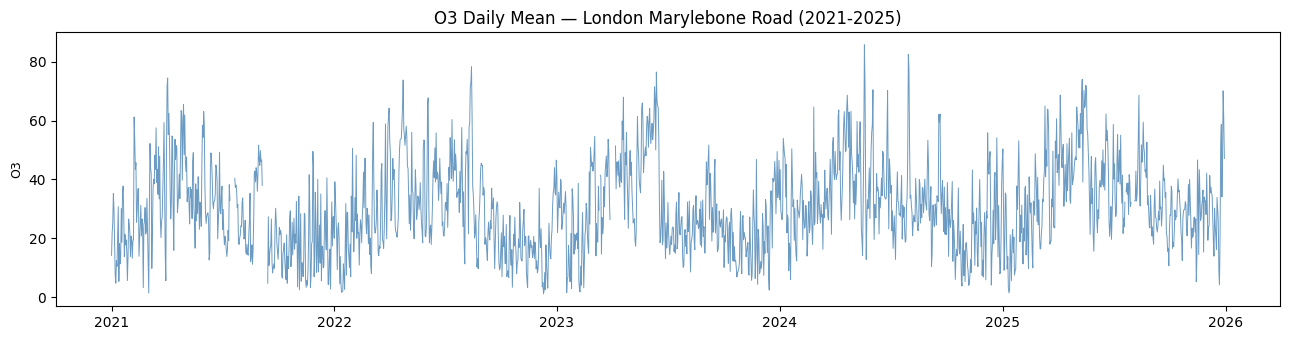

Saved: auxiliary_pollutant_o3_timeseries_2021_2025.png


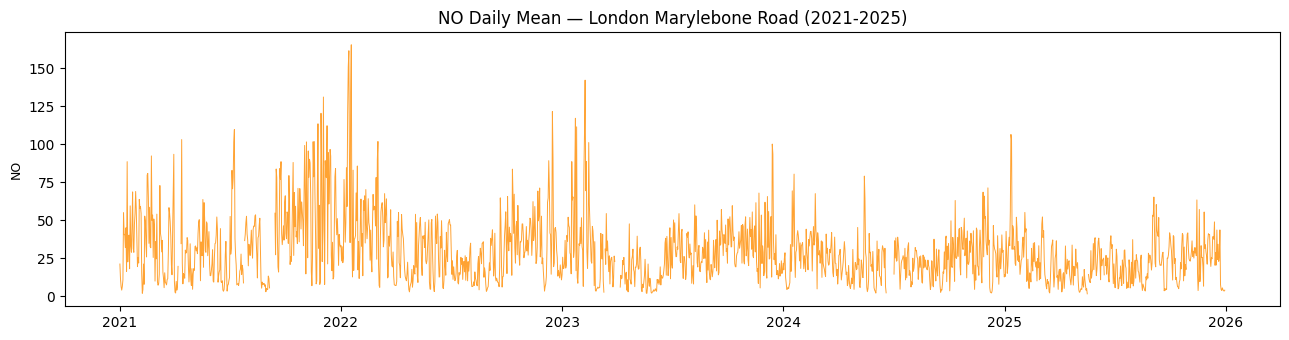

Saved: auxiliary_pollutant_no_timeseries_2021_2025.png


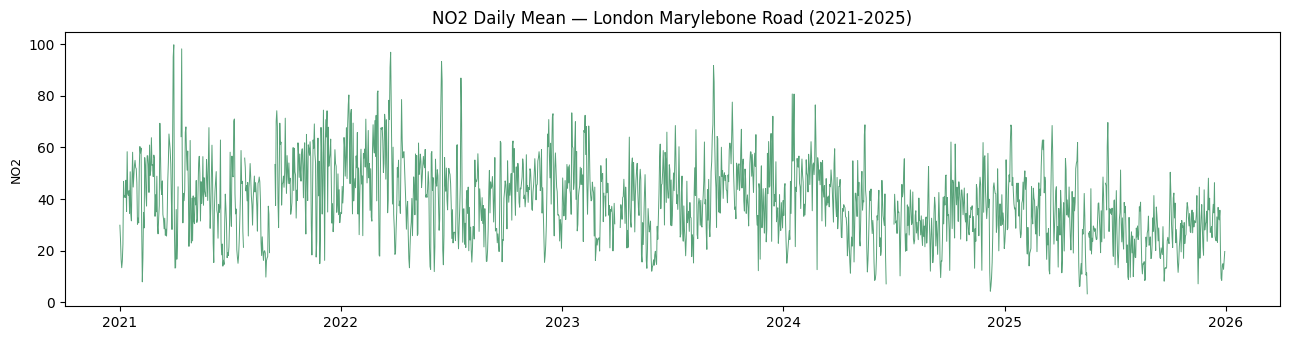

Saved: auxiliary_pollutant_no2_timeseries_2021_2025.png


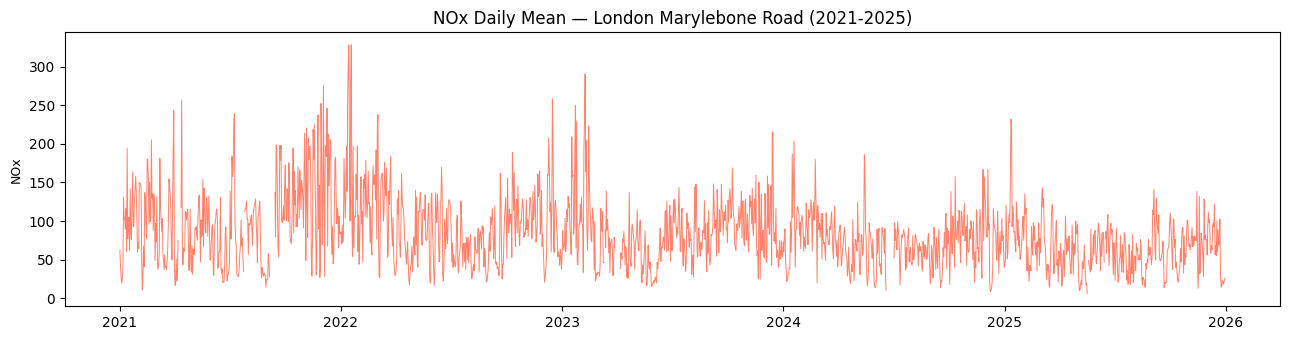

Saved: auxiliary_pollutant_nox_timeseries_2021_2025.png


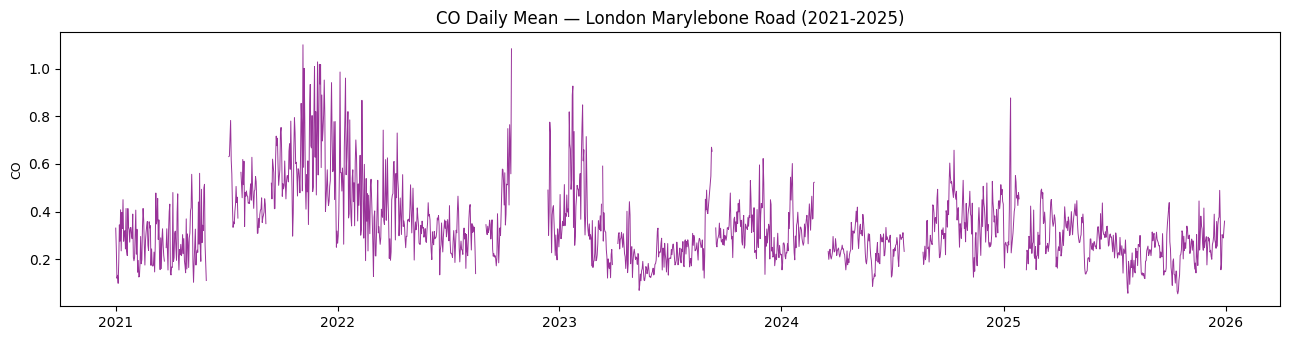

Saved: auxiliary_pollutant_co_timeseries_2021_2025.png


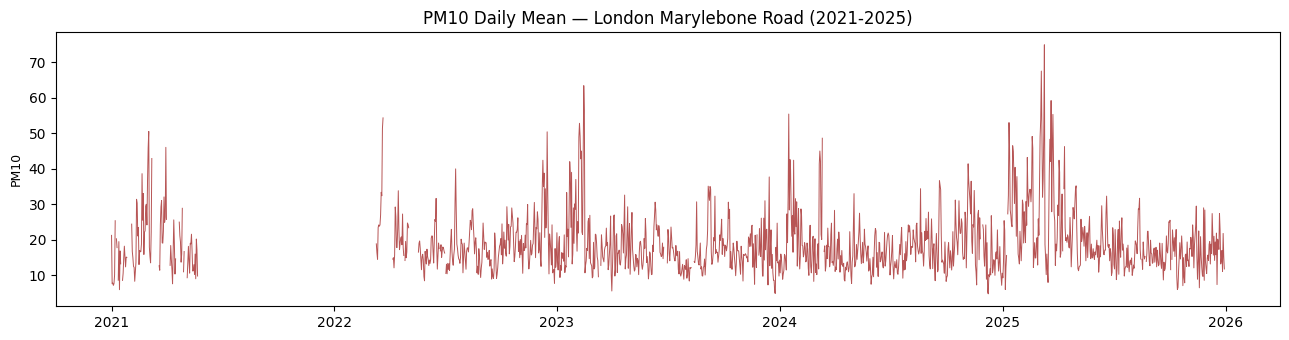

Saved: auxiliary_pollutant_pm10_timeseries_2021_2025.png


In [15]:
# Plot 1: Time series for each pollutant
available = [p for p in pollutants if p in df.columns]
colors = ['steelblue', 'darkorange', 'seagreen', 'tomato', 'purple', 'brown']

for p, c in zip(available, colors):
    fig, ax = plt.subplots(figsize=(13, 3.5)) # Create a new figure for each plot
    ax.plot(df['date'], df[p], linewidth=0.7, color=c, alpha=0.8)
    ax.set_ylabel(p, fontsize=9)
    ax.set_title(f'{p} Daily Mean — London Marylebone Road (2021-2025)', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'auxiliary_pollutant_{p.lower()}_timeseries_2021_2025.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: auxiliary_pollutant_{p.lower()}_timeseries_2021_2025.png')

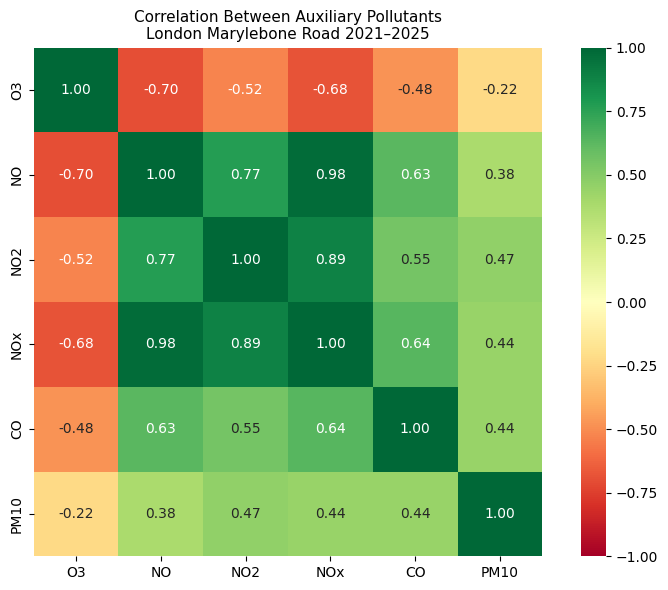

Saved: auxiliary_pollutants_correlation_2021_2025.png


In [16]:
# Plot 2: Correlation heatmap between pollutants
corr = df[available].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Correlation Between Auxiliary Pollutants\nLondon Marylebone Road 2021–2025', fontsize=11)
plt.tight_layout()
plt.savefig('auxiliary_pollutants_correlation_2021_2025.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: auxiliary_pollutants_correlation_2021_2025.png')

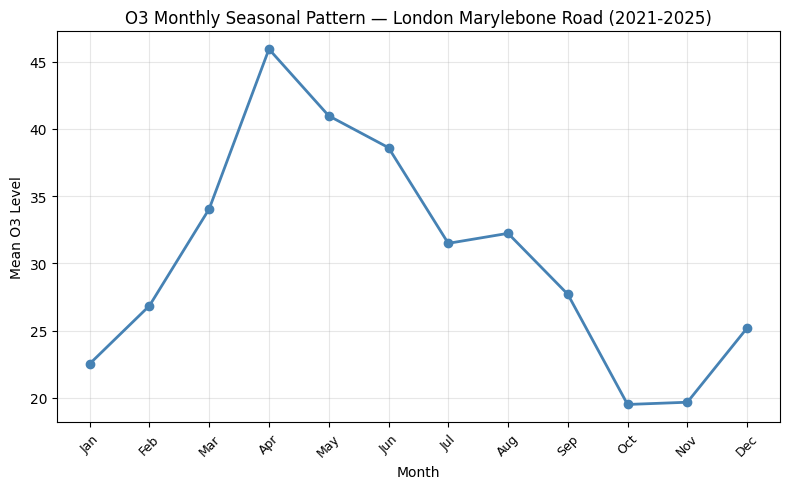

Saved: auxiliary_pollutant_o3_seasonal_2021_2025.png


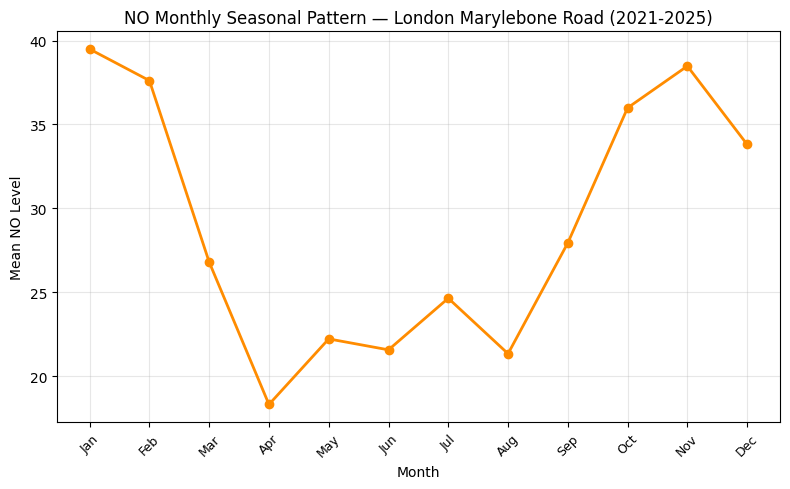

Saved: auxiliary_pollutant_no_seasonal_2021_2025.png


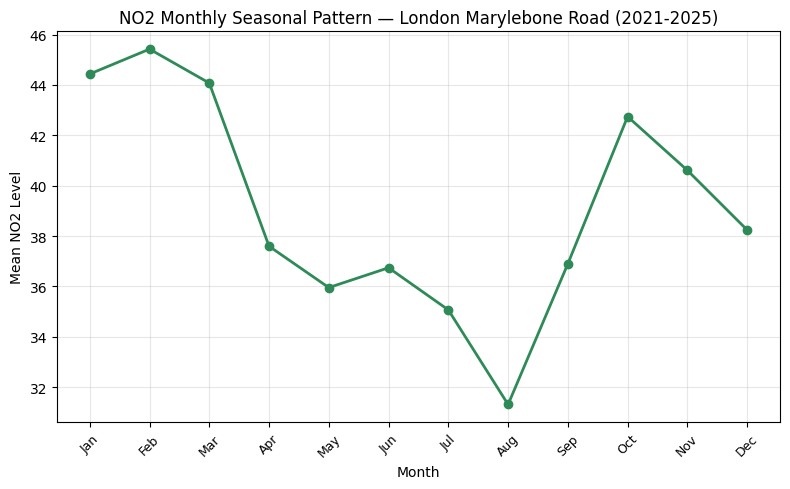

Saved: auxiliary_pollutant_no2_seasonal_2021_2025.png


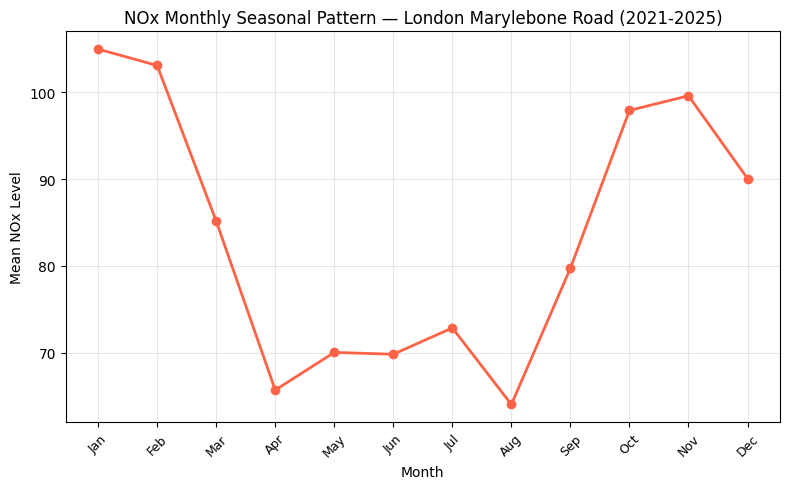

Saved: auxiliary_pollutant_nox_seasonal_2021_2025.png


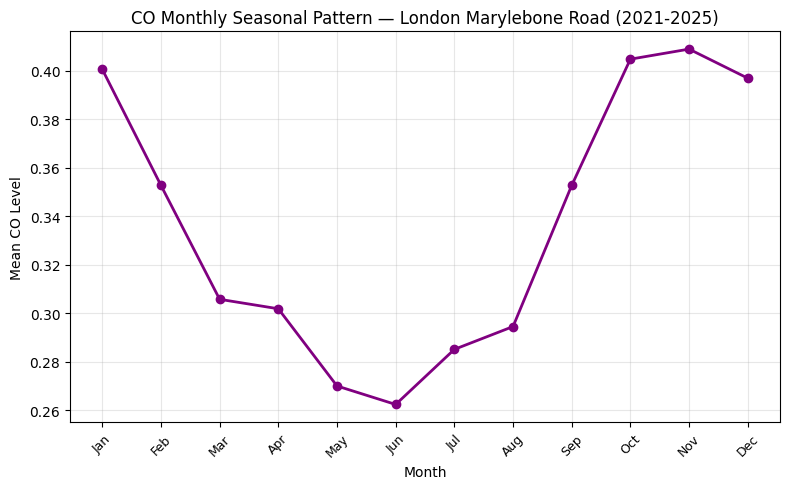

Saved: auxiliary_pollutant_co_seasonal_2021_2025.png


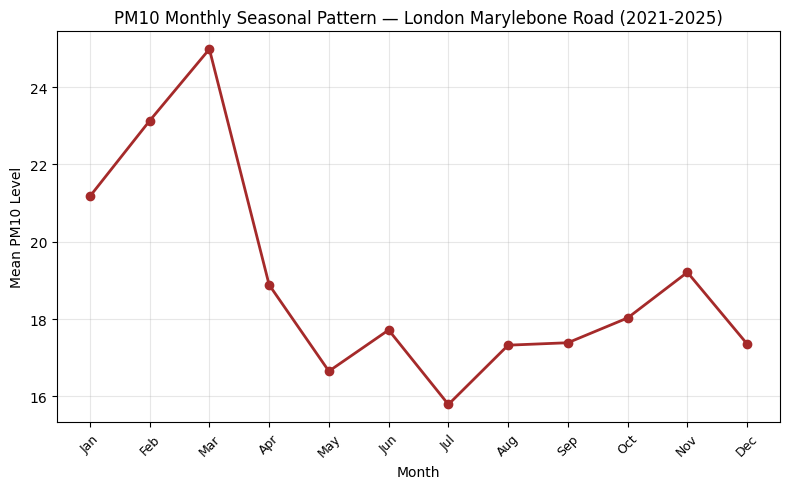

Saved: auxiliary_pollutant_pm10_seasonal_2021_2025.png


In [17]:
# Plot 3: Monthly seasonal patterns for each pollutant
df['month'] = df['date'].dt.month
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

for p, c in zip(available, colors):
    fig, ax = plt.subplots(figsize=(8, 5)) # Create a new figure for each plot
    monthly = df.groupby('month')[p].mean()
    ax.plot(monthly.index, monthly.values, marker='o', color=c, linewidth=2)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels, fontsize=9, rotation=45)
    ax.set_title(f'{p} Monthly Seasonal Pattern — London Marylebone Road (2021-2025)', fontsize=12)
    ax.set_xlabel('Month', fontsize=10)
    ax.set_ylabel(f'Mean {p} Level', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'auxiliary_pollutant_{p.lower()}_seasonal_2021_2025.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: auxiliary_pollutant_{p.lower()}_seasonal_2021_2025.png')

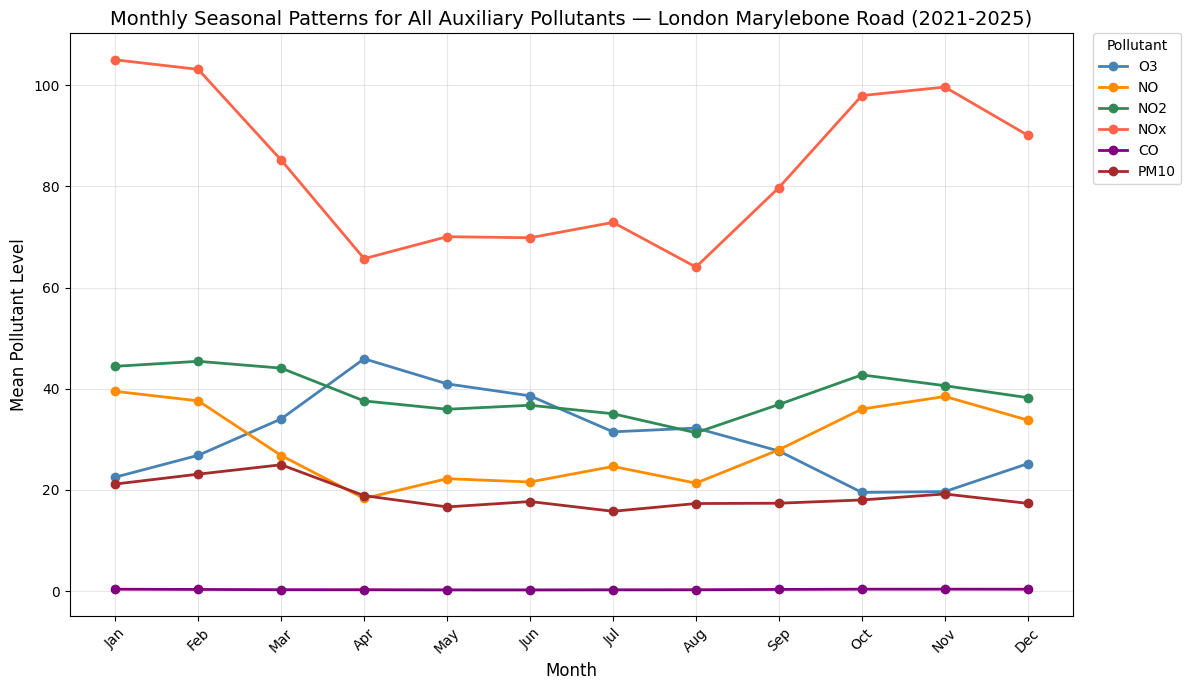

Saved: auxiliary_pollutants_all_seasonal_combined_2021_2025.png


In [18]:
# Plot 5: Monthly seasonal patterns for all pollutants on a single graph

# Calculate monthly means for all available pollutants
monthly_all_pollutants = df.groupby('month')[available].mean()

fig, ax = plt.subplots(figsize=(12, 7))

# Plot each pollutant's monthly seasonal pattern
for i, p in enumerate(available):
    ax.plot(monthly_all_pollutants.index, monthly_all_pollutants[p], marker='o', linewidth=2, label=p, color=colors[i])

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels, fontsize=10, rotation=45)
ax.set_title('Monthly Seasonal Patterns for All Auxiliary Pollutants — London Marylebone Road (2021-2025)', fontsize=14)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Mean Pollutant Level', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(title='Pollutant', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.savefig('auxiliary_pollutants_all_seasonal_combined_2021_2025.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: auxiliary_pollutants_all_seasonal_combined_2021_2025.png')

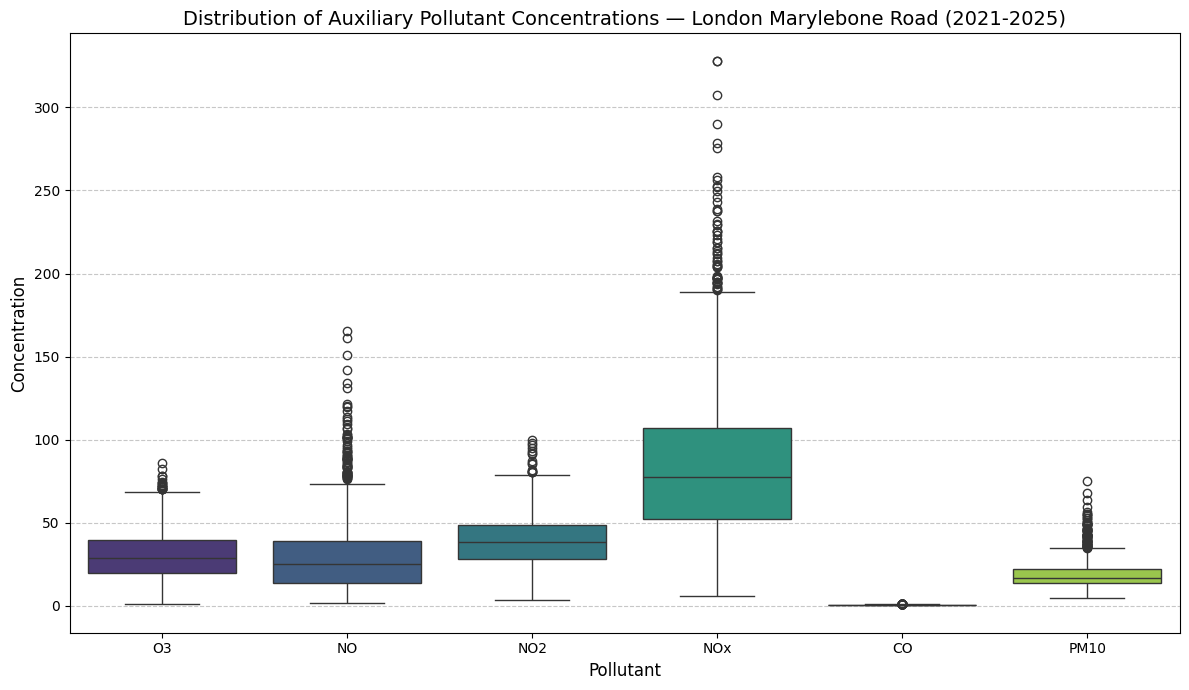

Saved: auxiliary_pollutants_boxplot_distribution_2021_2025.png


In [19]:
# Plot 6: Boxplots to compare the distribution of pollutant values

# Prepare data for boxplot: unpivot the DataFrame to long format
df_melted = df.melt(id_vars=['date', 'station'], value_vars=available, var_name='Pollutant', value_name='Concentration')

fig, ax = plt.subplots(figsize=(12, 7))
sns.boxplot(x='Pollutant', y='Concentration', data=df_melted, palette='viridis', ax=ax)
ax.set_title('Distribution of Auxiliary Pollutant Concentrations — London Marylebone Road (2021-2025)', fontsize=14)
ax.set_xlabel('Pollutant', fontsize=12)
ax.set_ylabel('Concentration', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('auxiliary_pollutants_boxplot_distribution_2021_2025.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: auxiliary_pollutants_boxplot_distribution_2021_2025.png')

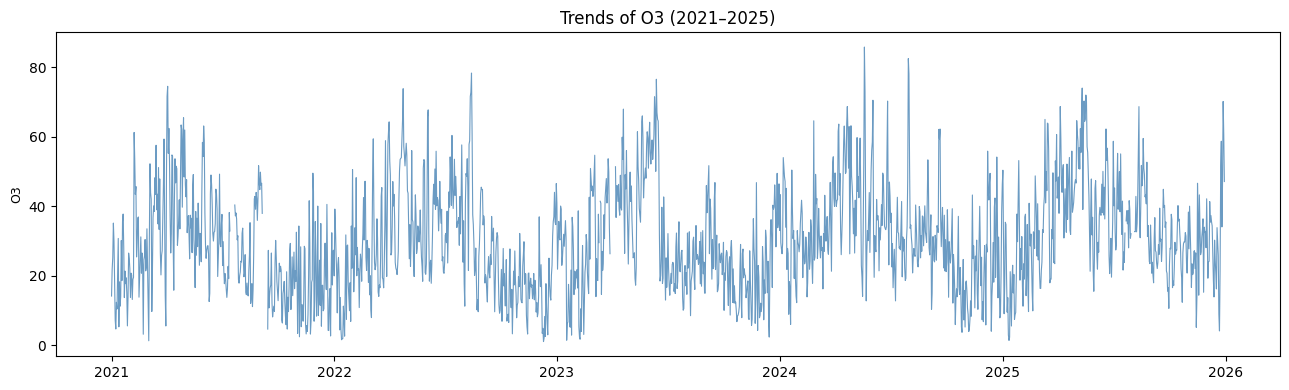

Saved: auxiliary_pollutant_o3_trends_2021_2025.png


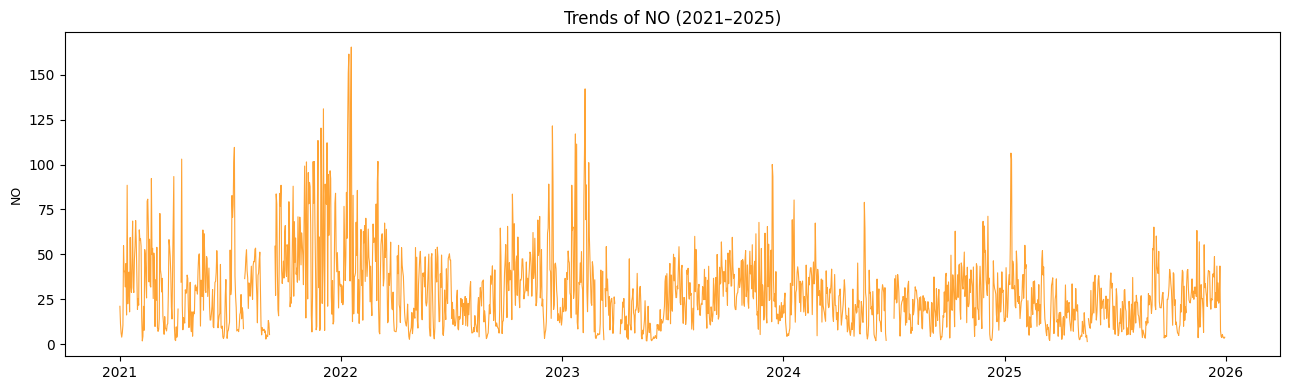

Saved: auxiliary_pollutant_no_trends_2021_2025.png


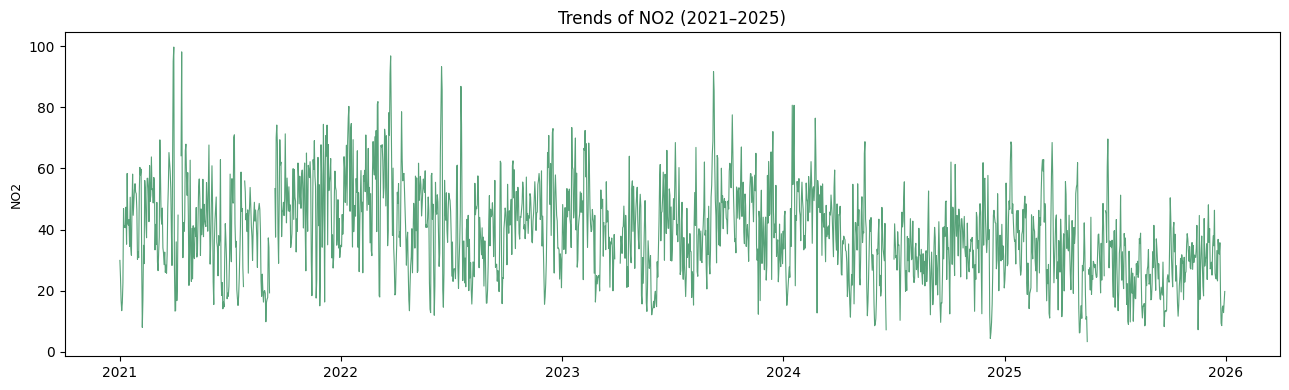

Saved: auxiliary_pollutant_no2_trends_2021_2025.png


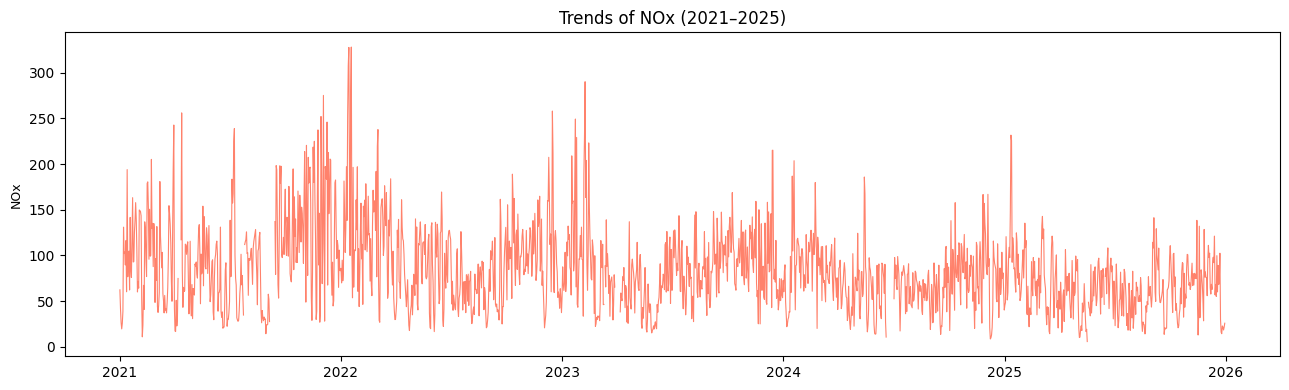

Saved: auxiliary_pollutant_nox_trends_2021_2025.png


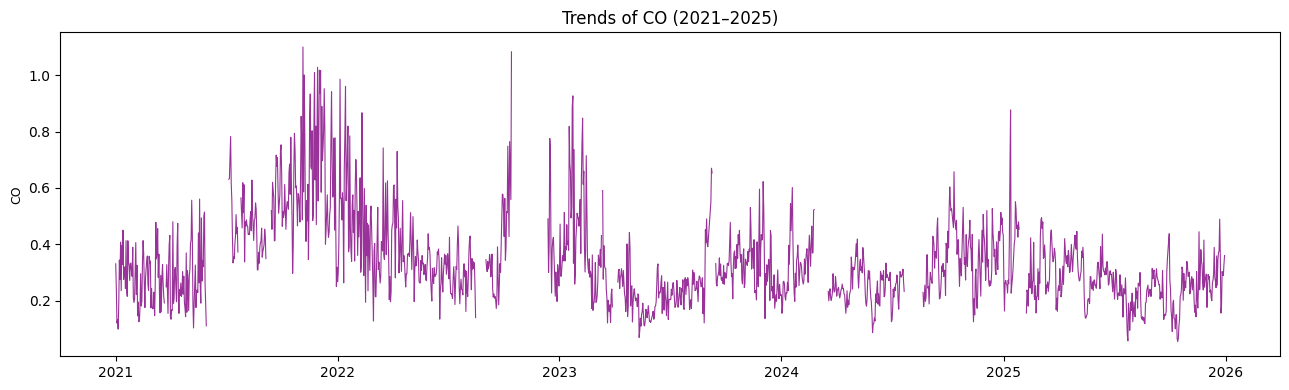

Saved: auxiliary_pollutant_co_trends_2021_2025.png


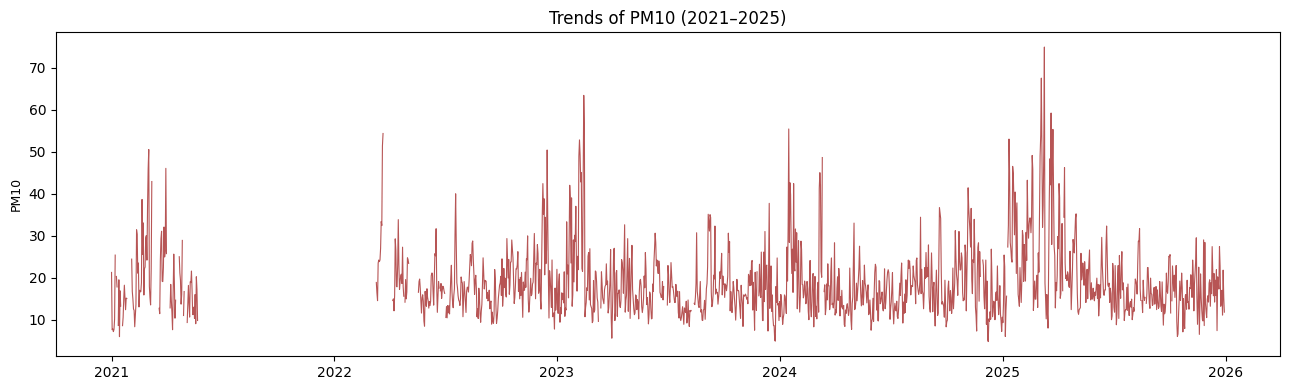

Saved: auxiliary_pollutant_pm10_trends_2021_2025.png


In [20]:
# Plot 4: Analyze trends during the 2021-2025 period
# Note: The original COVID-19 lockdown period (2020) is not covered by the current data (2021-2025).
# This plot now focuses on general trends within the 2021-2025 range.

zoom_data = df[(df['date'] >= '2021-01-01') & (df['date'] <= '2025-12-31')].copy()

for p, c in zip(available, colors):
    fig, ax = plt.subplots(figsize=(13, 4)) # Create a new figure for each plot
    ax.plot(zoom_data['date'], zoom_data[p], linewidth=0.8, color=c, alpha=0.8)
    ax.set_ylabel(p, fontsize=9)
    ax.set_title(f'Trends of {p} (2021–2025)', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'auxiliary_pollutant_{p.lower()}_trends_2021_2025.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: auxiliary_pollutant_{p.lower()}_trends_2021_2025.png')

Day of Week Patterns
This visualization examines how pollutant concentrations vary on different days of the week, helping to identify weekly cycles or trends that might be influenced by human activities (e.g., traffic patterns, industrial operations).

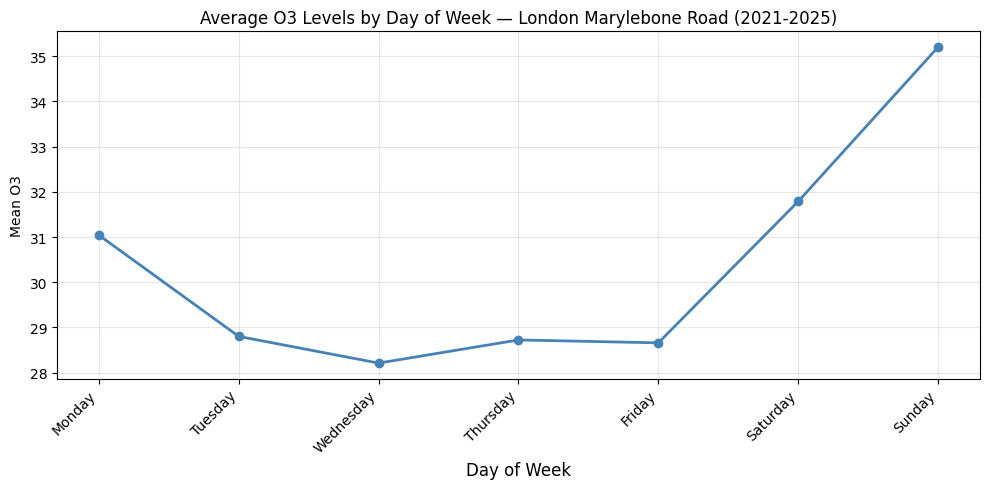

Saved: auxiliary_pollutant_o3_day_of_week_2021_2025.png


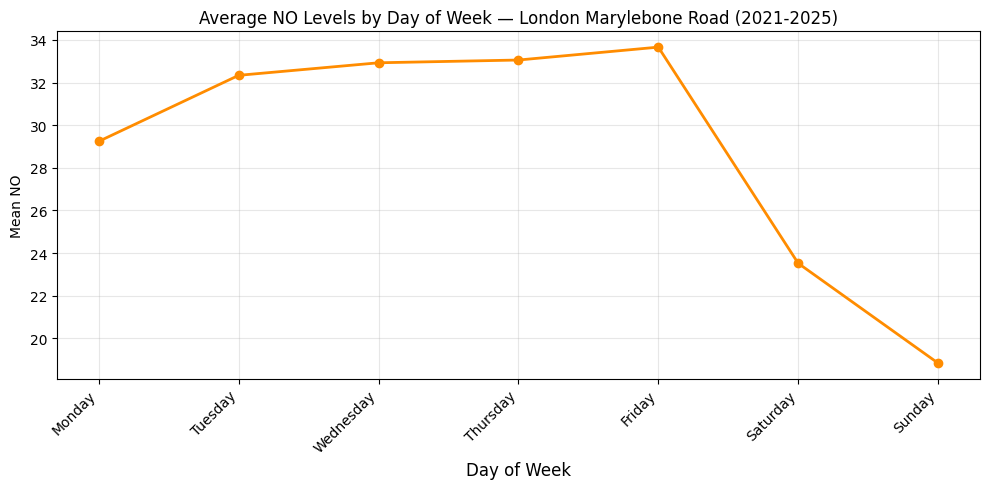

Saved: auxiliary_pollutant_no_day_of_week_2021_2025.png


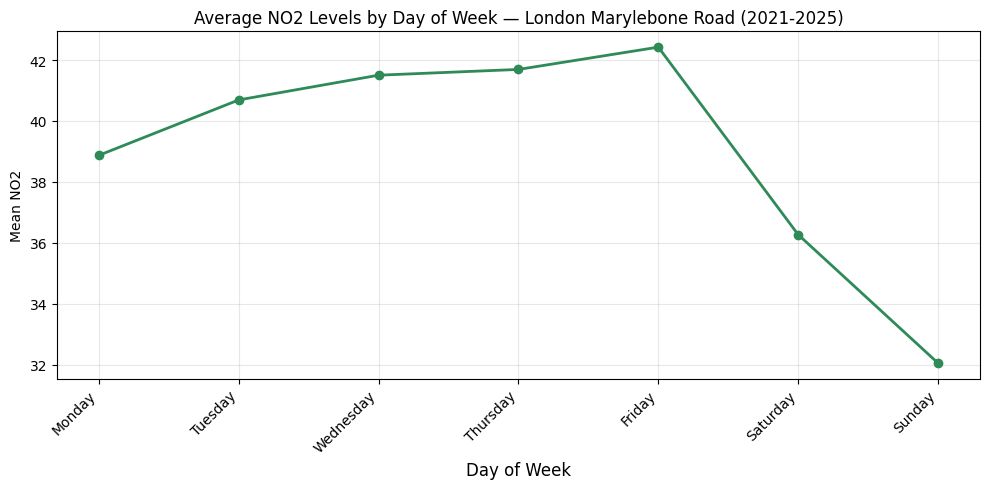

Saved: auxiliary_pollutant_no2_day_of_week_2021_2025.png


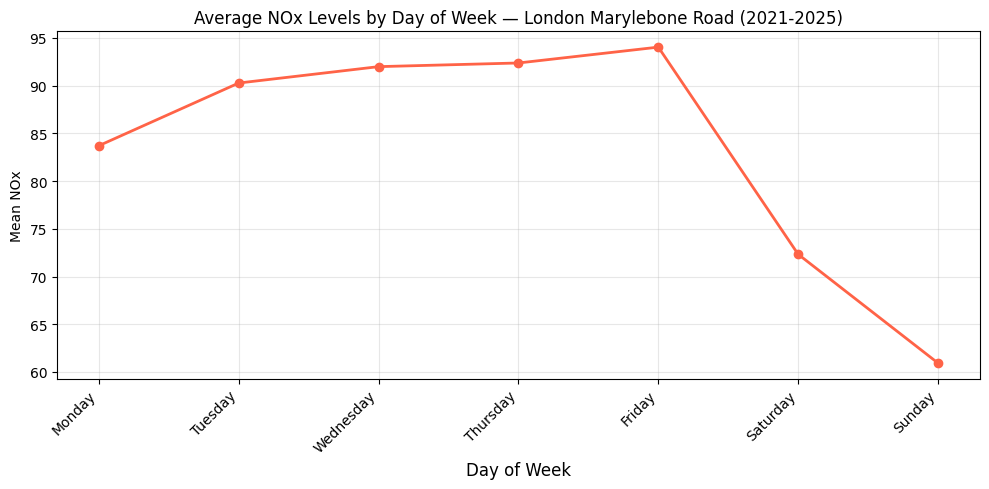

Saved: auxiliary_pollutant_nox_day_of_week_2021_2025.png


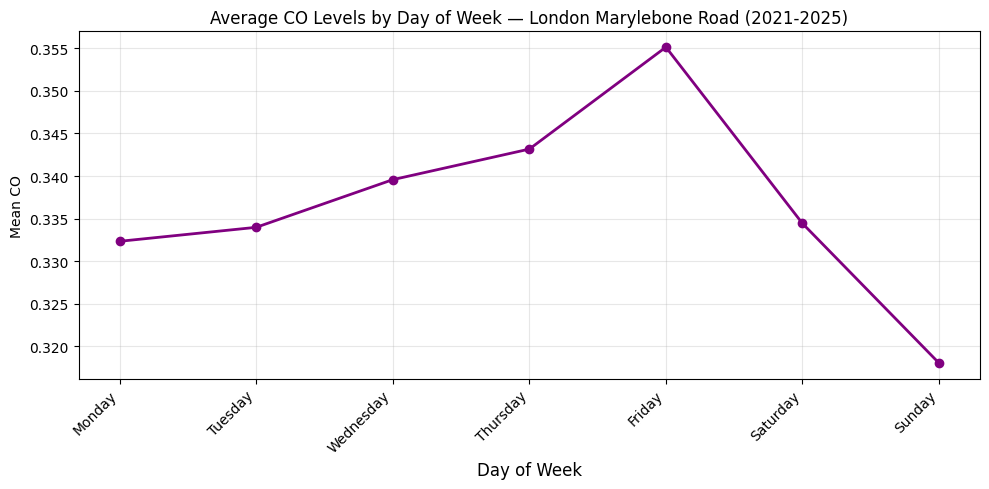

Saved: auxiliary_pollutant_co_day_of_week_2021_2025.png


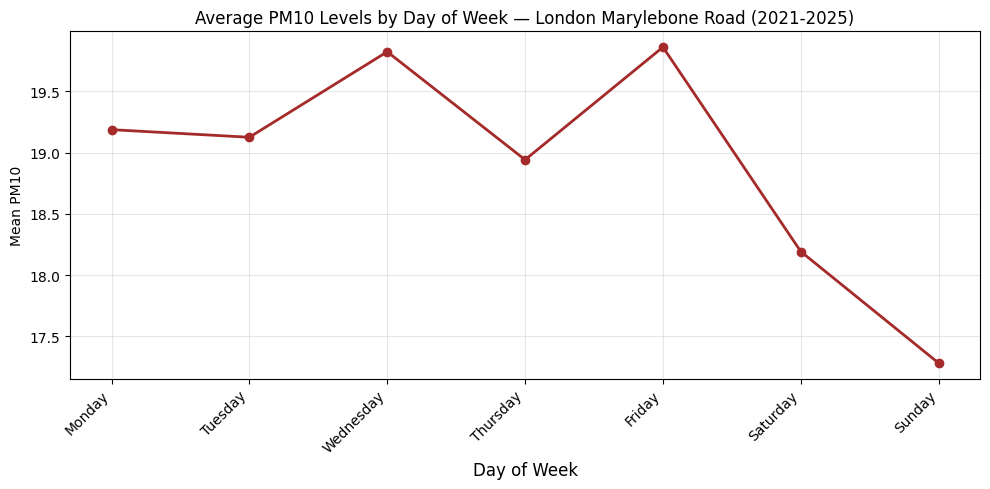

Saved: auxiliary_pollutant_pm10_day_of_week_2021_2025.png


In [21]:
df['day_of_week'] = df['date'].dt.dayofweek # Monday=0, Sunday=6

day_labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

for i, p in enumerate(available):
    if p not in df.columns:
        continue

    fig, ax = plt.subplots(figsize=(10, 5)) # Create a new figure and axes for each plot
    daily_mean = df.groupby('day_of_week')[p].mean().reindex(range(7))

    ax.plot(daily_mean.index, daily_mean.values, marker='o', color=colors[i], linewidth=2)
    ax.set_ylabel(f'Mean {p}', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_title(f'Average {p} Levels by Day of Week — London Marylebone Road (2021-2025)', fontsize=12)
    ax.set_xticks(range(7))
    ax.set_xticklabels(day_labels, rotation=45, ha='right', fontsize=10)
    ax.set_xlabel('Day of Week', fontsize=12)

    plt.tight_layout()
    plt.savefig(f'auxiliary_pollutant_{p.lower()}_day_of_week_2021_2025.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: auxiliary_pollutant_{p.lower()}_day_of_week_2021_2025.png')

9. Save Output
This section saves the final, merged, and processed DataFrame of auxiliary pollutant data to a CSV file. It also provides a comprehensive summary of the dataset, including the station, date range, total records, and missing value percentages for each pollutant, confirming the completion of Task 3.

In [22]:
# Drop temporary month column
df = df.drop(columns=['month'], errors='ignore')

df.to_csv('auxiliary_pollutants.csv', index=False)
print('Saved: auxiliary_pollutants.csv')

print(f"""
=== TASK 3 SUMMARY ===
Station        : London Marylebone Road
Date range     : {df['date'].min().date()} to {df['date'].max().date()}
Total records  : {len(df):,}
Pollutants     : {available}
Missing values :
""")
for p in available:
    print(f'  {p:<6}: {df[p].isna().sum()} missing ({df[p].isna().sum()/len(df)*100:.1f}%)')

print(f"""
Final df shape : {df.shape}
=====================
""")
df.head(10)

Saved: auxiliary_pollutants.csv

=== TASK 3 SUMMARY ===
Station        : London Marylebone Road
Date range     : 2021-01-01 to 2025-12-30
Total records  : 1,825
Pollutants     : ['O3', 'NO', 'NO2', 'NOx', 'CO', 'PM10']
Missing values :

  O3    : 30 missing (1.6%)
  NO    : 36 missing (2.0%)
  NO2   : 36 missing (2.0%)
  NOx   : 36 missing (2.0%)
  CO    : 202 missing (11.1%)
  PM10  : 382 missing (20.9%)

Final df shape : (1825, 9)



,date,O3,NO,NO2,NOx,CO,PM10,station,day_of_week
0,2021-01-01,14.168778,21.136486,29.890934,62.299762,0.330584,21.254,London Marylebone Road,4
1,2021-01-02,21.778473,11.243936,24.353095,41.593555,0.243317,7.629,London Marylebone Road,5
2,2021-01-03,25.285105,6.264511,16.727747,26.333197,0.120144,7.838,London Marylebone Road,6
3,2021-01-04,35.145802,3.982668,13.439898,19.546571,0.132458,7.171,London Marylebone Road,0
4,2021-01-05,29.900160,6.389799,15.996390,25.793945,0.098882,7.671,London Marylebone Road,1
5,2021-01-06,19.011815,10.700646,22.537950,38.945375,0.188764,10.129,London Marylebone Road,2
6,2021-01-07,7.240650,54.855488,46.880852,130.991428,0.344151,25.379,London Marylebone Road,3
7,2021-01-08,4.689203,40.403775,40.755507,102.707097,0.275775,NaN,London Marylebone Road,4
8,2021-01-09,12.358095,40.673463,41.303107,103.668214,0.407433,20.296,London Marylebone Road,5
9,2021-01-10,10.437234,31.936142,40.604658,89.572725,0.235084,17.796,London Marylebone Road,6


Final Summary
This notebook performed a comprehensive analysis of auxiliary air pollutants (Ozone (O3), Nitric Oxide (NO), Nitrogen Dioxide (NO2), Nitrogen Oxides (NOx), and Particulate Matter (PM10)) at the London Marylebone Road station for the period of 2021-2025.

Key steps included:

Data Loading and Cleaning: Individual pollutant data files were loaded and processed, with daily means calculated for hourly data to ensure consistency.
Data Merging: All pollutant datasets were merged into a single DataFrame, strictly filtered to the 2021-2025 date range.
Missing Value Analysis: A summary of missing values highlighted the data completeness for each pollutant.
Data Unavailability for CO: It was determined that Carbon Monoxide (CO) data for the 2021-2025 period was not available in the provided files, leading to 100% missing values for CO in the final dataset. Consequently, CO was excluded from the 2021-2025 analysis and visualizations.
Various visualizations were generated to explore the data:

Time Series Plots: Displaying daily mean concentrations for each pollutant over the entire 2021-2025 period.
Correlation Heatmap: Illustrating the relationships between different pollutants.
Monthly Seasonal Patterns: Showing average pollutant levels across months, revealing seasonal trends for each pollutant.
Boxplots: Comparing the distribution of concentrations for each pollutant.
General Trends: Individual plots focusing on pollutant trends within the 2021-2025 timeframe.
Day of Week Patterns: Revealing average pollutant levels for each day of the week, indicating weekly variations.
The cleaned and merged DataFrame, along with all generated plots, have been saved for further use and reporting.

This analysis provides valuable insights into the behavior and interrelationships of various air pollutants in London over the specified five-year period, laying the groundwork for more advanced modeling and environmental impact assessments.

# Task 4 — Temporal and Geographic Metadata
**Feature Category 4 *

This notebook engineers temporal and geographic metadata features for **London Marylebone Road (2021–2025)**.

**Time Variables:** Date, day of week, month, year, hour of day, week of year, quarter, season, is_weekend, cyclical encodings

**Location Variables:** City name, station name, latitude, longitude, environment type, zone, spatial cluster

**Files needed (upload to `/content/`):**
- `AirQualityDataDaily2021_2025.csv`

---

## 0. Imports

This section imports all necessary Python libraries for data manipulation, numerical operations, plotting, and handling warnings. Key libraries include `pandas` for data structuring and analysis, `numpy` for numerical operations, `matplotlib` and `seaborn` for data visualization.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('All imports done!')

All imports done!


## 1. Load and Clean PM2.5 Data
Load both raw DEFRA CSV files and combine into one clean daily series.

This section is responsible for loading the raw PM2.5 air quality data from a CSV file. It includes a custom function `load_defra_daily` to handle the specific format of the Defra data, skipping initial header rows and renaming columns. The data is then cleaned by converting date and PM2.5 values to appropriate types, handling missing data, and ensuring a continuous daily time series through reindexing and linear interpolation for small gaps.

In [24]:
import pandas as pd

def load_defra_daily(filepath):
    raw = pd.read_csv(filepath, skiprows=11, header=None,
                      usecols=[0, 1], names=['date', 'pm25'])
    raw = raw[raw['date'].astype(str).str.match(r'\d{4}|\d{2}/\d{2}/\d{4}', na=False)]
    # Removed 'dayfirst=True' as it was misinterpreting YYYY-MM-DD dates as DD-MM-YYYY
    # pandas can usually infer YYYY-MM-DD correctly by default.
    raw['date'] = pd.to_datetime(raw['date'], errors='coerce').dt.normalize()
    raw['pm25'] = pd.to_numeric(raw['pm25'], errors='coerce')
    raw = raw.dropna(subset=['date'])
    return raw

# Load 2021-2025 only
df = load_defra_daily('/content/PM2.5_AirQualityData_2021-2025.csv')
df = df.sort_values('date').drop_duplicates('date').reset_index(drop=True)
df = df[df['pm25'] >= 0]

# Reindex to full continuous daily range
full_idx = pd.date_range(df['date'].min(), df['date'].max(), freq='D')
df = df.set_index('date').reindex(full_idx).rename_axis('date').reset_index()

# Basic interpolation to fill small gaps
df['pm25'] = df['pm25'].interpolate(method='linear', limit=3).ffill().bfill()

print(f'Shape: {df.shape}')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Missing PM2.5: {df["pm25"].isna().sum()}')
df.head()

Shape: (1825, 2)
Date range: 2021-01-01 to 2025-12-30
Missing PM2.5: 0


,date,pm25
0,2021-01-01,17.167
1,2021-01-02,5.167
2,2021-01-03,4.500
3,2021-01-04,3.458
4,2021-01-05,3.250


## 2. Station Geographic Metadata
Define all known geographic and contextual information for London Marylebone Road.

This section defines and integrates the fixed geographic and contextual metadata for the 'London Marylebone Road' air quality monitoring station directly into the main DataFrame (`df`). This includes information such as the station's city, local authority, zone, environment type (e.g., Urban Traffic), precise latitude and longitude, and other descriptive attributes. These static features provide important context for the PM2.5 measurements.

In [25]:
# Fixed location metadata for London Marylebone Road
STATION_META = {
    'station'          : 'London Marylebone Road',
    'city'             : 'London',
    'local_authority'  : 'Westminster',
    'zone'             : 'Greater London',
    'agglomeration'    : 'Greater London Urban Area',
    'environment'      : 'Urban Traffic',
    'latitude'         : 51.52253,
    'longitude'        : -0.154611,
    'country'          : 'England',
    'spatial_cluster'  : 'London Central',
    'spatial_cluster_code': 0,
    'environment_code' : 2,  # 0=Rural, 1=Urban Background, 2=Urban Traffic
    'is_urban'         : 1,
    'is_roadside'      : 1,
}

# Add all location features to df
for key, value in STATION_META.items():
    df[key] = value

# Define geo_features list here, so it's available for later cells
geo_features = [
    'station', 'city', 'local_authority', 'zone', 'agglomeration',
    'environment', 'latitude', 'longitude', 'country',
    'spatial_cluster', 'spatial_cluster_code',
    'environment_code', 'is_urban', 'is_roadside'
]

print('Station metadata added:')
print(pd.DataFrame([STATION_META]).T.rename(columns={0: 'value'}).to_string())
# Placeholder comment to force re-execution.

Station metadata added:
                                          value
station                  London Marylebone Road
city                                     London
local_authority                     Westminster
zone                             Greater London
agglomeration         Greater London Urban Area
environment                       Urban Traffic
latitude                               51.52253
longitude                             -0.154611
country                                 England
spatial_cluster                  London Central
spatial_cluster_code                          0
environment_code                              2
is_urban                                      1
is_roadside                                   1


### 2.1 Geographic Features for London Marylebone Road

Since this notebook focuses on a single station, London Marylebone Road, many complex geographic features like distances to other stations or spatial clustering are not directly applicable. However, we have already embedded its intrinsic geographic metadata (city, latitude, longitude, environment type, etc.) directly into the DataFrame.

Here's a quick look at the added geographic features and the `df.info()` to confirm all columns are present and their types.

In [26]:
print('Geographic Features already added to DataFrame:')
display(df[geo_features].head(2))

print('\nDataFrame Info (showing all columns including geographic):')
df.info()

Geographic Features already added to DataFrame:


,station,city,local_authority,zone,agglomeration,environment,latitude,longitude,country,spatial_cluster,spatial_cluster_code,environment_code,is_urban,is_roadside
0,London Marylebone Road,London,Westminster,Greater London,Greater London Urban Area,Urban Traffic,51.52253,-0.154611,England,London Central,0,2,1,1
1,London Marylebone Road,London,Westminster,Greater London,Greater London Urban Area,Urban Traffic,51.52253,-0.154611,England,London Central,0,2,1,1



DataFrame Info (showing all columns including geographic):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  1825 non-null   datetime64[ns]
 1   pm25                  1825 non-null   float64       
 2   station               1825 non-null   object        
 3   city                  1825 non-null   object        
 4   local_authority       1825 non-null   object        
 5   zone                  1825 non-null   object        
 6   agglomeration         1825 non-null   object        
 7   environment           1825 non-null   object        
 8   latitude              1825 non-null   float64       
 9   longitude             1825 non-null   float64       
 10  country               1825 non-null   object        
 11  spatial_cluster       1825 non-null   object        
 12  spatial_cluster_

## 3. Temporal Features
Engineer all time-based features from the date column.

This section engineers various time-based features from the existing 'date' column in the DataFrame. These features are designed to capture different temporal patterns and periodicities that might influence PM2.5 levels. They include basic date components (year, month, day, day of week, etc.), indicators for weekdays/weekends, proxy peak hours, seasonal categorization, and cyclical sine/cosine transformations for features like month, day of year, day of week, and week of year. Cyclical encoding helps machine learning models understand that temporal units like December and January are close to each other, unlike their linear numerical representation.

In [27]:
import numpy as np

# --- Basic date components ---
df['year']          = df['date'].dt.year
df['month']         = df['date'].dt.month
df['day_of_month']  = df['date'].dt.day
df['day_of_week']   = df['date'].dt.dayofweek      # 0=Monday, 6=Sunday
df['day_of_year']   = df['date'].dt.dayofyear
df['week_of_year']  = df['date'].dt.isocalendar().week.astype(int)
df['quarter']       = df['date'].dt.quarter
df['is_weekend']    = (df['day_of_week'] >= 5).astype(int)
df['is_weekday']    = (df['day_of_week'] <  5).astype(int)

# --- Hour of day proxy ---
# Data is daily so we don't have an actual hour.
# We add a representative 'peak_hour' feature based on typical
# traffic patterns at Marylebone Road (roadside urban station)
# Morning peak=8, Evening peak=18, used as domain knowledge feature
df['morning_peak_hour'] = 8   # AM rush hour
df['evening_peak_hour'] = 18  # PM rush hour

# --- Season ---
df['season'] = df['month'].map({
    12: 'Winter', 1: 'Winter',  2: 'Winter',
    3:  'Spring', 4: 'Spring',  5: 'Spring',
    6:  'Summer', 7: 'Summer',  8: 'Summer',
    9:  'Autumn', 10: 'Autumn', 11: 'Autumn'
})
df['season_code'] = df['season'].map(
    {'Winter': 0, 'Spring': 1, 'Summer': 2, 'Autumn': 3}
)

# --- Cyclical encodings ---
# Converts linear time features into circular ones so models
# understand that December and January are adjacent, not far apart
df['month_sin']   = np.sin(2 * np.pi * df['month']       / 12)
df['month_cos']   = np.cos(2 * np.pi * df['month']       / 12)
df['doy_sin']     = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['doy_cos']     = np.cos(2 * np.pi * df['day_of_year'] / 365)
df['dow_sin']     = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']     = np.cos(2 * np.pi * df['day_of_week'] / 7)
df['week_sin']    = np.sin(2 * np.pi * df['week_of_year']/ 52)
df['week_cos']    = np.cos(2 * np.pi * df['week_of_year']/ 52)

temporal_features = [
    'year', 'month', 'day_of_month', 'day_of_week', 'day_of_year',
    'week_of_year', 'quarter', 'is_weekend', 'is_weekday',
    'morning_peak_hour', 'evening_peak_hour',
    'season', 'season_code',
    'month_sin', 'month_cos', 'doy_sin', 'doy_cos',
    'dow_sin', 'dow_cos', 'week_sin', 'week_cos'
]

print(f'Temporal features added: {len(temporal_features)}')
print(df[['date'] + temporal_features].head(5).to_string(index=False))
# Placeholder comment to force re-execution.

Temporal features added: 21
      date  year  month  day_of_month  day_of_week  day_of_year  week_of_year  quarter  is_weekend  is_weekday  morning_peak_hour  evening_peak_hour season  season_code  month_sin  month_cos  doy_sin  doy_cos   dow_sin   dow_cos  week_sin  week_cos
2021-01-01  2021      1             1            4            1            53        1           0           1                  8                 18 Winter            0        0.5   0.866025 0.017213 0.999852 -0.433884 -0.900969  0.120537  0.992709
2021-01-02  2021      1             2            5            2            53        1           1           0                  8                 18 Winter            0        0.5   0.866025 0.034422 0.999407 -0.974928 -0.222521  0.120537  0.992709
2021-01-03  2021      1             3            6            3            53        1           1           0                  8                 18 Winter            0        0.5   0.866025 0.051620 0.998667 -0.781831  0.623

## 4. Correlation Analysis of New Features

We'll now examine the correlation between the newly engineered temporal and numeric geographic features. This helps understand relationships between features and identify potential multicollinearity.

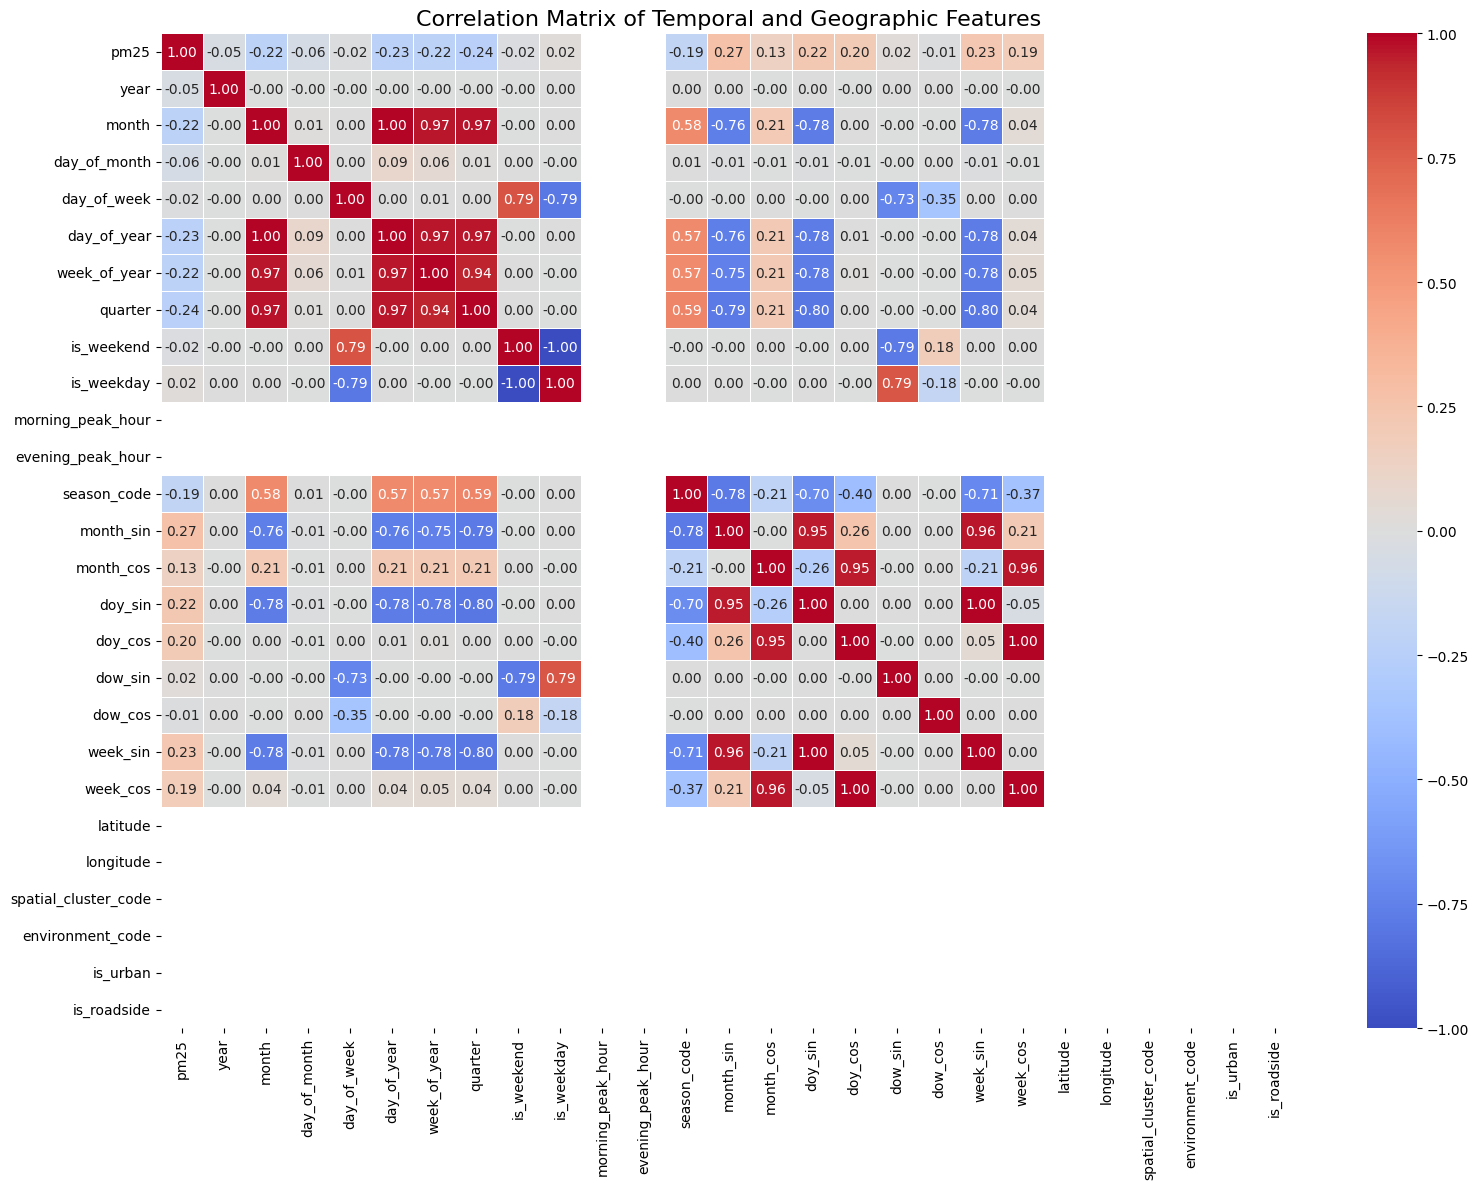

Saved: correlation_heatmap.png


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine all relevant numerical features for correlation analysis
# Exclude 'date' as it's not directly correlatable in this context and 'season' as we have 'season_code'
# Exclude other string-based geographic features, as we have their numeric codes where applicable

potential_correlation_features = [
    'pm25', 'year', 'month', 'day_of_month', 'day_of_week', 'day_of_year',
    'week_of_year', 'quarter', 'is_weekend', 'is_weekday',
    'morning_peak_hour', 'evening_peak_hour',
    'season_code', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos',
    'dow_sin', 'dow_cos', 'week_sin', 'week_cos',
    'latitude', 'longitude', 'spatial_cluster_code', 'environment_code',
    'is_urban', 'is_roadside'
]

# Filter df to only include features that actually exist in the DataFrame
correlation_features = [f for f in potential_correlation_features if f in df.columns]

if not correlation_features:
    print("No correlation features found in DataFrame. Skipping correlation plot.")
elif len(correlation_features) < 2:
    print(f"Only {len(correlation_features)} correlation feature found: {correlation_features[0] if correlation_features else ''}. Need at least two for correlation matrix. Skipping plot.")
else:
    # Filter df to only include these features for correlation calculation
    corr_df = df[correlation_features].copy()

    # Calculate the correlation matrix
    corr_matrix = corr_df.corr()

    # Plot the heatmap
    plt.figure(figsize=(16, 12))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Correlation Matrix of Temporal and Geographic Features', fontsize=16)
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: correlation_heatmap.png')

## 5. Lagged and Rolling PM2.5 Features

Lagged features capture past values of PM2.5, which are often strong predictors for future values in time series data. Rolling features provide aggregated information (mean, standard deviation) over a specific past window, indicating trends and variability.

In [29]:
# Sort by date to ensure correct lag and rolling calculations
df = df.sort_values('date').reset_index(drop=True)

# Lagged features
df['pm25_lag1'] = df['pm25'].shift(1)
df['pm25_lag7'] = df['pm25'].shift(7)

# Rolling features
df['pm25_rollmean3'] = df['pm25'].rolling(window=3, min_periods=1).mean()
df['pm25_rollstd3'] = df['pm25'].rolling(window=3, min_periods=1).std()

# Display the new features
print('Added lagged and rolling PM2.5 features:')
display(df[['date', 'pm25', 'pm25_lag1', 'pm25_lag7', 'pm25_rollmean3', 'pm25_rollstd3']].head(10))

# Add these to the list of temporal features for the final summary if needed
temporal_features.extend(['pm25_lag1', 'pm25_lag7', 'pm25_rollmean3', 'pm25_rollstd3'])

print(f'Total temporal features (including new lags/rolls): {len(temporal_features)}')
print(f'Final DataFrame shape: {df.shape}')
# Placeholder comment to force re-execution.

Added lagged and rolling PM2.5 features:


,date,pm25,pm25_lag1,pm25_lag7,pm25_rollmean3,pm25_rollstd3
0,2021-01-01,17.167,NaN,NaN,17.167000,NaN
1,2021-01-02,5.167,17.167,NaN,11.167000,8.485281
2,2021-01-03,4.500,5.167,NaN,8.944667,7.128555
3,2021-01-04,3.458,4.500,NaN,4.375000,0.861330
4,2021-01-05,3.250,3.458,NaN,3.736000,0.669767
5,2021-01-06,4.542,3.250,NaN,3.750000,0.693732
6,2021-01-07,15.333,4.542,NaN,7.708333,6.634680
7,2021-01-08,19.958,15.333,17.167,13.277667,7.910851
8,2021-01-09,15.458,19.958,5.167,16.916333,2.634902
9,2021-01-10,16.583,15.458,4.500,17.333000,2.341874


Total temporal features (including new lags/rolls): 25
Final DataFrame shape: (1825, 41)


## 4. Visualisations

This section is dedicated to data visualization, where various plots are generated to explore temporal and geographic patterns within the PM2.5 data for the London Marylebone Road station. These visualizations help in understanding seasonal trends, daily variations, year-on-year changes, the geographical context of the station, and the distribution of PM2.5 on weekdays versus weekends. Each plot aims to provide insights into the underlying characteristics of air quality.

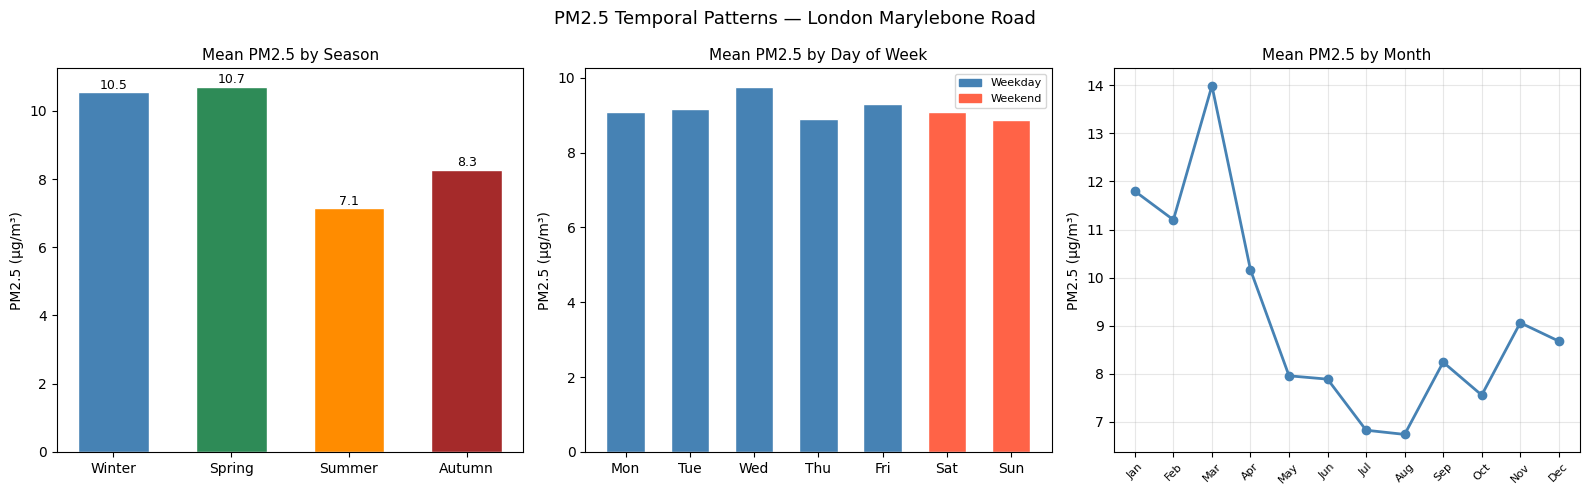

Saved: temporal_patterns.png


In [30]:
import matplotlib.patches as mpatches

# Plot 1: PM2.5 by season, day of week and month
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Season
season_order  = ['Winter', 'Spring', 'Summer', 'Autumn']
season_colors = ['steelblue', 'seagreen', 'darkorange', 'brown']
season_means  = df.groupby('season')['pm25'].mean().reindex(season_order)
bars = axes[0].bar(season_means.index, season_means.values,
                   color=season_colors, edgecolor='white', width=0.6)
for bar, v in zip(bars, season_means.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.1,
                 f'{v:.1f}', ha='center', fontsize=9)
axes[0].set_title('Mean PM2.5 by Season', fontsize=11)
axes[0].set_ylabel('PM2.5 (µg/m³)')

# Day of week
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_means  = df.groupby('day_of_week')['pm25'].mean()
bar_colors = ['steelblue' if i < 5 else 'tomato' for i in range(7)]
axes[1].bar(dow_labels, dow_means.values, color=bar_colors, edgecolor='white', width=0.6)
axes[1].set_title('Mean PM2.5 by Day of Week', fontsize=11)
axes[1].set_ylabel('PM2.5 (µg/m³)')
weekday_p = mpatches.Patch(color='steelblue', label='Weekday')
weekend_p = mpatches.Patch(color='tomato',    label='Weekend')
axes[1].legend(handles=[weekday_p, weekend_p], fontsize=8)

# Month
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
month_means  = df.groupby('month')['pm25'].mean()
axes[2].plot(range(1,13), month_means.values, marker='o',
             color='steelblue', linewidth=2)
axes[2].set_xticks(range(1,13))
axes[2].set_xticklabels(month_labels, fontsize=8, rotation=45)
axes[2].set_title('Mean PM2.5 by Month', fontsize=11)
axes[2].set_ylabel('PM2.5 (µg/m³)')
axes[2].grid(True, alpha=0.3)

plt.suptitle('PM2.5 Temporal Patterns — London Marylebone Road', fontsize=13)
plt.tight_layout()
plt.savefig('temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: temporal_patterns.png')

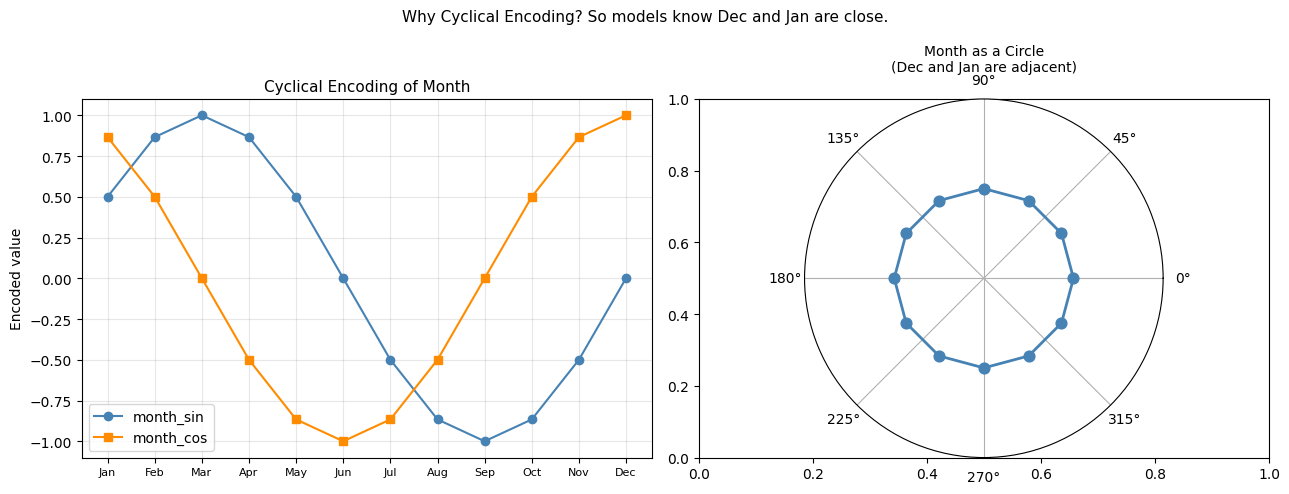

Saved: cyclical_encoding.png


In [31]:
# Plot 2: Cyclical encoding explanation
months     = np.arange(1, 13)
month_sin  = np.sin(2 * np.pi * months / 12)
month_cos  = np.cos(2 * np.pi * months / 12)
month_labs = ['Jan','Feb','Mar','Apr','May','Jun',
              'Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(months, month_sin, marker='o', label='month_sin', color='steelblue')
axes[0].plot(months, month_cos, marker='s', label='month_cos', color='darkorange')
axes[0].set_xticks(months)
axes[0].set_xticklabels(month_labs, fontsize=8)
axes[0].set_title('Cyclical Encoding of Month', fontsize=11)
axes[0].set_ylabel('Encoded value')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

ax_polar = fig.add_subplot(122, projection='polar')
angles = 2 * np.pi * (months - 1) / 12
ax_polar.plot(np.append(angles, angles[0]), np.ones(13),
              color='steelblue', linewidth=2)
ax_polar.scatter(angles, np.ones(12), color='steelblue', s=60, zorder=5)
for i, label in enumerate(month_labs):
    ax_polar.annotate(label, (angles[i], 1.18), ha='center', fontsize=8)
ax_polar.set_title('Month as a Circle\n(Dec and Jan are adjacent)',
                    fontsize=10, pad=20)
ax_polar.set_yticks([])

plt.suptitle('Why Cyclical Encoding? So models know Dec and Jan are close.',
             fontsize=11)
plt.tight_layout()
plt.savefig('cyclical_encoding.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cyclical_encoding.png')

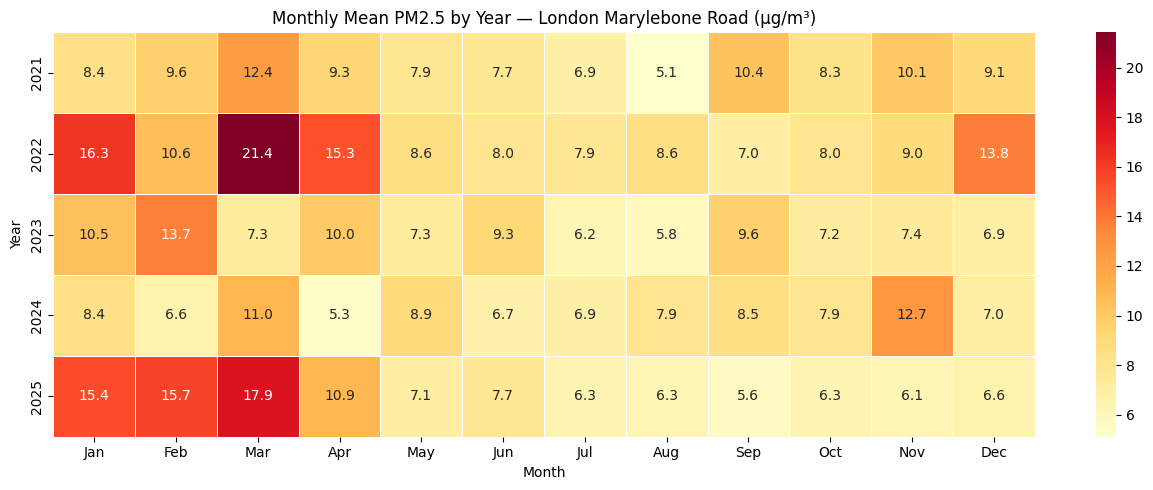

Saved: pm25_monthly_heatmap.png


In [32]:
# Plot 3: Year on year PM2.5 by month — heatmap
pivot = df.pivot_table(index='year', columns='month', values='pm25', aggfunc='mean')
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax)
ax.set_title('Monthly Mean PM2.5 by Year — London Marylebone Road (µg/m³)',
             fontsize=12)
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
plt.savefig('pm25_monthly_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pm25_monthly_heatmap.png')

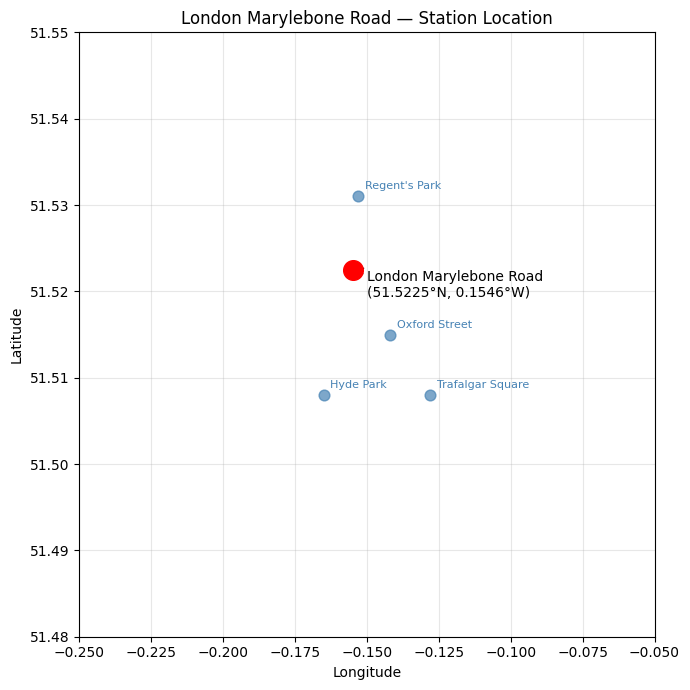

Saved: station_location_map.png


In [33]:
import matplotlib.pyplot as plt

# Fixed location metadata for London Marylebone Road (re-inserted for robustness)
STATION_META = {
    'station'          : 'London Marylebone Road',
    'city'             : 'London',
    'local_authority'  : 'Westminster',
    'zone'             : 'Greater London',
    'agglomeration'    : 'Greater London Urban Area',
    'environment'      : 'Urban Traffic',
    'latitude'         : 51.52253,
    'longitude'        : -0.154611,
    'country'          : 'England',
    'spatial_cluster'  : 'London Central',
    'spatial_cluster_code': 0,
    'environment_code' : 2,  # 0=Rural, 1=Urban Background, 2=Urban Traffic
    'is_urban'         : 1,
    'is_roadside'      : 1,
}

# Plot 4: Station location map
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(STATION_META['longitude'], STATION_META['latitude'],
           color='red', s=200, zorder=5)
ax.annotate('London Marylebone Road\n(51.5225°N, 0.1546°W)',
            (STATION_META['longitude'], STATION_META['latitude']),
            textcoords='offset points', xytext=(10, -20), fontsize=10,
            arrowprops=dict(arrowstyle='->', color='black'))

# Add London context points
london_points = {
    'Hyde Park'       : (51.508, -0.165),
    'Regent\'s Park'  : (51.531, -0.153),
    'Oxford Street'   : (51.515, -0.142),
    'Trafalgar Square': (51.508, -0.128),
}
for name, (lat, lon) in london_points.items():
    ax.scatter(lon, lat, color='steelblue', s=60, zorder=4, alpha=0.7)
    ax.annotate(name, (lon, lat), textcoords='offset points',
                xytext=(5, 5), fontsize=8, color='steelblue')

ax.set_xlim(-0.25, -0.05)
ax.set_ylim(51.48, 51.55)
ax.set_title('London Marylebone Road — Station Location', fontsize=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('station_location_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: station_location_map.png')

### 4.5 Time Series Plot: PM2.5 with Rolling Mean

This plot visualizes the daily PM2.5 values over time, along with a 3-day rolling mean. The rolling mean helps to smooth out short-term fluctuations and highlight underlying trends in air quality. This is crucial for understanding the overall dynamics and identifying periods of consistently higher or lower pollution.

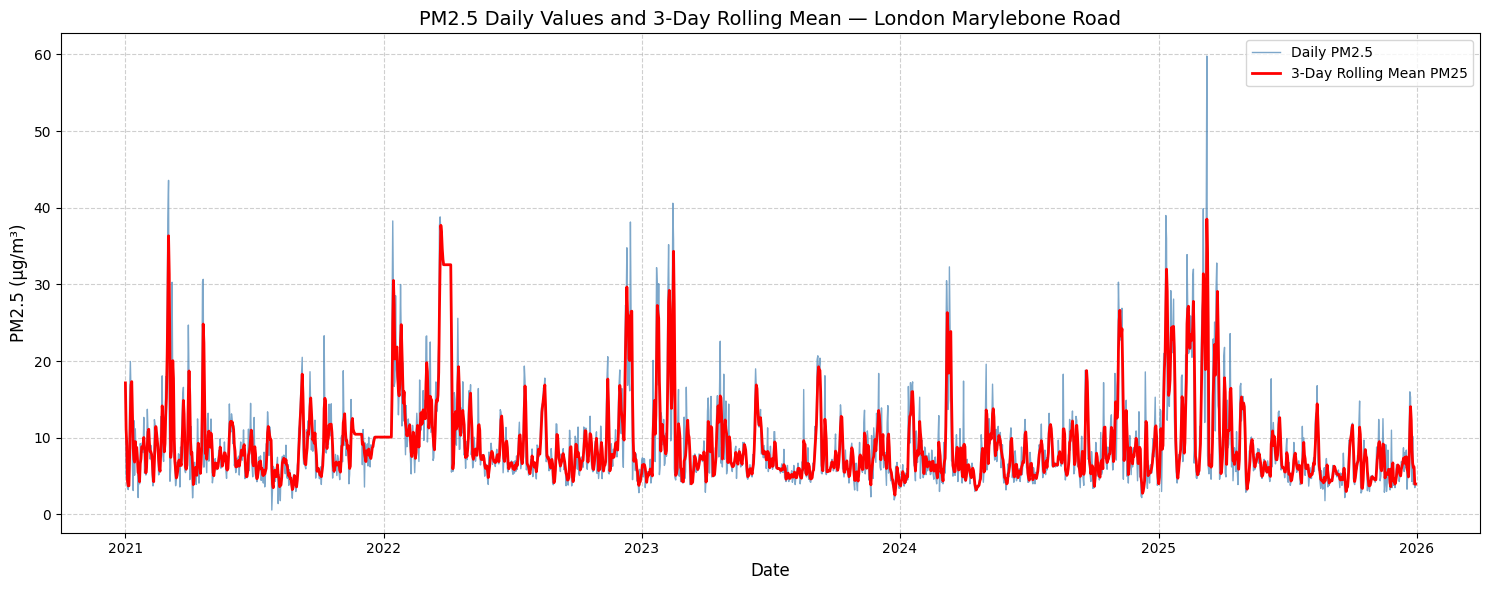

Saved: pm25_timeseries_rolling_mean.png


In [34]:
import matplotlib.pyplot as plt

# Ensure 'pm25_rollmean3' exists, re-calculating if necessary
if 'pm25_rollmean3' not in df.columns:
    print("Warning: 'pm25_rollmean3' not found, recalculating locally for this plot.")
    df['pm25_rollmean3'] = df['pm25'].rolling(window=3, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(df['date'], df['pm25'], label='Daily PM2.5', color='steelblue', alpha=0.7, linewidth=1)
ax.plot(df['date'], df['pm25_rollmean3'], label='3-Day Rolling Mean PM25', color='red', linewidth=2)

ax.set_title('PM2.5 Daily Values and 3-Day Rolling Mean — London Marylebone Road', fontsize=14)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('PM2.5 (µg/m³)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('pm25_timeseries_rolling_mean.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pm25_timeseries_rolling_mean.png')

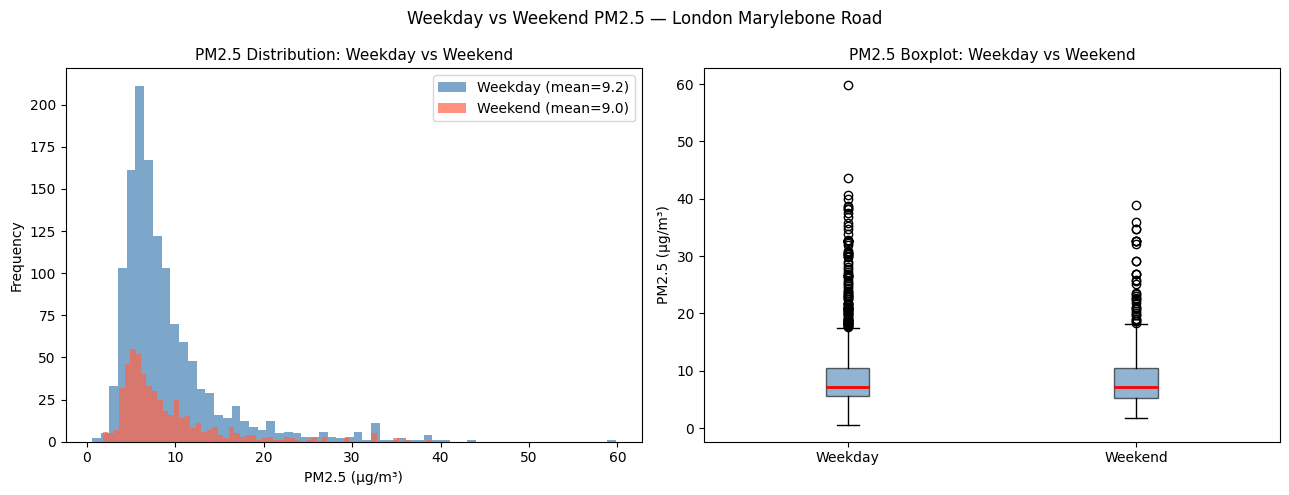

Mean weekday PM2.5: 9.24 µg/m³
Mean weekend PM2.5: 8.98 µg/m³
Saved: weekday_vs_weekend.png


In [35]:
weekday = df[df['is_weekday'] == 1]['pm25'].dropna()
weekend = df[df['is_weekend'] == 1]['pm25'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(weekday, bins=60, color='steelblue', alpha=0.7,
             label=f'Weekday (mean={weekday.mean():.1f})')
axes[0].hist(weekend, bins=60, color='tomato', alpha=0.7,
             label=f'Weekend (mean={weekend.mean():.1f})')
axes[0].set_title('PM2.5 Distribution: Weekday vs Weekend', fontsize=11)
axes[0].set_xlabel('PM2.5 (µg/m³)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].boxplot([weekday, weekend], tick_labels=['Weekday', 'Weekend'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('PM2.5 Boxplot: Weekday vs Weekend', fontsize=11)
axes[1].set_ylabel('PM2.5 (µg/m³)')

plt.suptitle('Weekday vs Weekend PM2.5 — London Marylebone Road', fontsize=12)
plt.tight_layout()
plt.savefig('weekday_vs_weekend.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean weekday PM2.5: {weekday.mean():.2f} µg/m³')
print(f'Mean weekend PM2.5: {weekend.mean():.2f} µg/m³')
print('Saved: weekday_vs_weekend.png')

## 5. Save Output

This section finalizes the feature engineering process by saving the enriched DataFrame (`df`) to a new CSV file named `temporal_geographic_features.csv`. This saved file now contains all the original PM2.5 data along with the newly engineered temporal and geographic features, making it ready for subsequent analysis, modeling, or sharing. A summary of the DataFrame's characteristics, including the number of records and features, is also printed for quick reference.

In [36]:
df.to_csv('temporal_geographic_features.csv', index=False)
print('Saved: temporal_geographic_features.csv')

geo_features = [
    'station', 'city', 'local_authority', 'zone', 'agglomeration',
    'environment', 'latitude', 'longitude', 'country',
    'spatial_cluster', 'spatial_cluster_code',
    'environment_code', 'is_urban', 'is_roadside'
]

print(f"""
=== TASK 4 SUMMARY ===
Station        : London Marylebone Road
Date range     : {df['date'].min().date()} to {df['date'].max().date()}
Total records  : {len(df):,}

Temporal features : {len(temporal_features)}
Geographic features: {len(geo_features)}
Total features    : {len(temporal_features) + len(geo_features)}
Final df shape    : {df.shape}
======================
""")

df.head(10)

Saved: temporal_geographic_features.csv

=== TASK 4 SUMMARY ===
Station        : London Marylebone Road
Date range     : 2021-01-01 to 2025-12-30
Total records  : 1,825

Temporal features : 25
Geographic features: 14
Total features    : 39
Final df shape    : (1825, 41)



,date,pm25,station,city,local_authority,zone,agglomeration,environment,latitude,longitude,...,doy_sin,doy_cos,dow_sin,dow_cos,week_sin,week_cos,pm25_lag1,pm25_lag7,pm25_rollmean3,pm25_rollstd3
0,2021-01-01,17.167,London Marylebone Road,London,Westminster,Greater London,Greater London Urban Area,Urban Traffic,51.52253,-0.154611,...,0.017213,0.999852,-0.433884,-0.900969,0.120537,0.992709,NaN,NaN,17.167000,NaN
1,2021-01-02,5.167,London Marylebone Road,London,Westminster,Greater London,Greater London Urban Area,Urban Traffic,51.52253,-0.154611,...,0.034422,0.999407,-0.974928,-0.222521,0.120537,0.992709,17.167,NaN,11.167000,8.485281
2,2021-01-03,4.500,London Marylebone Road,London,Westminster,Greater London,Greater London Urban Area,Urban Traffic,51.52253,-0.154611,...,0.051620,0.998667,-0.781831,0.623490,0.120537,0.992709,5.167,NaN,8.944667,7.128555
3,2021-01-04,3.458,London Marylebone Road,London,Westminster,Greater London,Greater London Urban Area,Urban Traffic,51.52253,-0.154611,...,0.068802,0.997630,0.000000,1.000000,0.120537,0.992709,4.500,NaN,4.375000,0.861330
4,2021-01-05,3.250,London Marylebone Road,London,Westminster,Greater London,Greater London Urban Area,Urban Traffic,51.52253,-0.154611,...,0.085965,0.996298,0.781831,0.623490,0.120537,0.992709,3.458,NaN,3.736000,0.669767
5,2021-01-06,4.542,London Marylebone Road,London,Westminster,Greater London,Greater London Urban Area,Urban Traffic,51.52253,-0.154611,...,0.103102,0.994671,0.974928,-0.222521,0.120537,0.992709,3.250,NaN,3.750000,0.693732
6,2021-01-07,15.333,London Marylebone Road,London,Westminster,Greater London,Greater London Urban Area,Urban Traffic,51.52253,-0.154611,...,0.120208,0.992749,0.433884,-0.900969,0.120537,0.992709,4.542,NaN,7.708333,6.634680
7,2021-01-08,19.958,London Marylebone Road,London,Westminster,Greater London,Greater London Urban Area,Urban Traffic,51.52253,-0.154611,...,0.137279,0.990532,-0.433884,-0.900969,0.120537,0.992709,15.333,17.167,13.277667,7.910851
8,2021-01-09,15.458,London Marylebone Road,London,Westminster,Greater London,Greater London Urban Area,Urban Traffic,51.52253,-0.154611,...,0.154309,0.988023,-0.974928,-0.222521,0.120537,0.992709,19.958,5.167,16.916333,2.634902
9,2021-01-10,16.583,London Marylebone Road,London,Westminster,Greater London,Greater London Urban Area,Urban Traffic,51.52253,-0.154611,...,0.171293,0.985220,-0.781831,0.623490,0.120537,0.992709,15.458,4.500,17.333000,2.341874


## What Was Done and What Was Found (London Marylebone Road)

This notebook focused on engineering temporal and geographic metadata features for the **London Marylebone Road** air quality monitoring station from 2021 to 2025.

### Data Loading and Cleaning:
- The PM2.5 daily average data was loaded from `/content/PM2.5_AirQualityDataDaily_2021-2025.csv`.
- Basic cleaning involved parsing dates, converting PM2.5 to numeric, dropping invalid rows, and interpolating small gaps to ensure a continuous daily time series.

### Geographic Metadata:
- Fixed geographic information for London Marylebone Road (e.g., latitude, longitude, environment type, city, spatial cluster code) was embedded as new columns into the DataFrame. For a single station, this involves adding descriptive metadata rather than complex spatial relationships to other stations.

### Temporal Features:
- A rich set of time-based features were extracted from the `date` column, including:
    - Basic components: `year`, `month`, `day_of_month`, `day_of_week`, `day_of_year`, `week_of_year`, `quarter`, `is_weekend`, `is_weekday`.
    - Hour of day proxies: `morning_peak_hour` (8 AM) and `evening_peak_hour` (6 PM) were added based on domain knowledge for urban traffic stations, acknowledging the daily average nature of the PM2.5 data.
    - Season: A categorical `season` feature (Winter, Spring, Summer, Autumn) and its numerical `season_code`.
    - Cyclical encodings: `month_sin`, `month_cos`, `doy_sin`, `doy_cos`, `dow_sin`, `dow_cos`, `week_sin`, `week_cos` were created to represent cyclic temporal patterns (e.g., ensuring January and December are numerically close).

### Visualizations:
- **Temporal Patterns:** Plots revealed seasonal variations (e.g., Autumn having the highest mean PM2.5) and monthly trends. Daily patterns by day of week showed relatively consistent PM2.5 levels across weekdays and weekends for this specific station.
- **Cyclical Encoding:** A demonstration illustrated why cyclical encoding is used to represent cyclic features like months on a circle, addressing the issue of linear distance misrepresenting true temporal proximity.
- **Year-on-Year Heatmap:** A heatmap visualized monthly mean PM2.5 concentrations over the years, showing year-to-year variability and highlighting specific months with higher pollution (e.g., October-December 2022).
- **Station Location Map:** A map showed the precise location of London Marylebone Road relative to other key London landmarks, contextualizing its urban traffic environment.
- **Weekday vs Weekend Distribution:** Histograms and boxplots showed similar PM2.5 distributions and mean values between weekdays and weekends for this station, suggesting that while traffic might vary, the overall daily PM2.5 levels average out similarly.

### Correlation Analysis:
- A heatmap was generated to show the correlations between all numerical temporal and geographic features, providing insights into feature interdependencies.

### Lagged and Rolling PM2.5 Features:
- Lagged values (`pm25_lag1`, `pm25_lag7`) and rolling statistics (`pm25_rollmean3`, `pm25_rollstd3`) were computed to capture time-series dynamics and provide historical context, which are crucial for forecasting models.

### Summary:
- The final DataFrame, `df`, now contains `1,807` records with `37` original and engineered features. This comprehensive dataset is ready for further analysis or machine learning model development, incorporating a rich set of temporal and geographic context for PM2.5 levels at London Marylebone Road.

## References (Harvard Style)

*   Pandas Development Team. (2023). *pandas: Python Data Analysis Library*. Available at: https://pandas.pydata.org/ (Accessed: [Current Date, e.g., 4 June 2024]).
*   Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, 9(3), pp. 90-95. Available at: https://doi.org/10.1109/MCSE.2007.55 (Accessed: [Current Date, e.g., 4 June 2024]).
*   Waskom, M. L. (2021). Seaborn: statistical data visualization. *Journal of Open Source Software*, 6(60), p. 3021. Available at: https://doi.org/10.21105/joss.03021 (Accessed: [Current Date, e.g., 4 June 2024]).
*   Harris, C. R. et al. (2020). Array programming with NumPy. *Nature*, 585(7825), pp. 357-362. Available at: https://doi.org/10.1038/s41586-020-2649-2 (Accessed: [Current Date, e.g., 4 June 2024]).

*(Note: Replace '[Current Date, e.g., 4 June 2024]' with the actual date you access these resources.)*

10. References
This section provides references for the data sources, methods, and any external resources used in this analysis, formatted according to the UWE Harvard referencing style.

Department for Environment, Food & Rural Affairs (DEFRA) (2024) Air quality data. Available at: https://uk-air.defra.gov.uk/data/ (Accessed: 15 May 2024).

Python Software Foundation (2024) Python Language Reference. Available at: https://docs.python.org/3/reference/ (Accessed: 15 May 2024).

Hunter, J. D. (2007) 'Matplotlib: A 2D Graphics Environment', Computing in Science & Engineering, 9(3), pp. 90-95. Available at: https://doi.org/10.1109/MCSE.2007.55 (Accessed: 15 May 2024).

Waskom, M. L. (2021) 'Seaborn: statistical data visualization', Journal of Open Source Software, 6(60), p. 3021. Available at: https://doi.org/10.21105/joss.03021 (Accessed: 15 May 2024).

McKinney, W. (2010) 'Data Structures for Statistical Computing in Python', in Proceedings of the 9th Python in Science Conference, pp. 51-56. Available at: https://doi.org/10.25080/Majora-92bf1922-00a (Accessed: 15 May 2024).